In [34]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.make_bal_mask import make_bal_mask
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line
from processing.parameters import CONTINUUM_WINDOWS

from sparcl.client import SparclClient
from dl import queryClient as qc
from astropy.table import Table
from astropy.convolution import convolve, Gaussian1DKernel
from scipy.interpolate import interp1d
from datetime import datetime
from scipy.signal import argrelmin, argrelmax

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import json
import os

hamann_fits_path = "data/local/ERQs_core_all_MNRAS.fits"
hamann_coords_path = "data/core-ERQ-stats-coords.csv"
search_log_path = "data/local/hamann-objects-sdss-search-log.json"
hamann_sdss_spectra_path = "data/local/hamann_sdss_spectra.json"
relevant_erq_data_path = "data/relevant_erq_data.csv"


# client = SparclClient()

### find spectra

In [3]:
hamann_coords = pd.read_csv(hamann_coords_path, index_col=0)

hamann_coords

,SDSS_id,RA,DEC,ze,i,i-W3,REW,REW_unc,FWHM,FWHM_unc,kt80,NV/CIV,BAL,UV_slope,E(B-V),E(B-V)_unc,FIRST
0,J000610.67+121501.2,1.544491,12.250354,2.31,22.1,8.0,107.0,6.0,4540.0,200.0,0.37,1.88,0,-0.20,0.66,0.01,0.0
1,J000746.19+122223.9,1.942491,12.373315,2.43,21.3,4.9,220.0,6.0,2433.0,71.0,0.28,0.39,0,-0.17,0.19,0.01,0.0
2,J002400.25+245031.9,6.001042,24.842208,2.81,21.6,6.0,144.0,10.0,3523.0,195.0,0.37,2.46,0,-1.14,0.20,0.02,NaN
3,J004713.21+264024.7,11.805059,26.673525,2.56,20.4,4.7,101.0,2.0,3685.0,74.0,0.33,1.92,1,-1.08,0.15,0.01,NaN
4,J005044.95-021217.6,12.687326,-2.204915,2.25,21.5,4.7,147.0,9.0,4343.0,487.0,0.19,0.61,0,-1.73,0.14,0.02,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,J223754.52+065026.6,339.477177,6.840747,2.61,22.0,5.8,141.0,5.0,1391.0,44.0,0.36,1.03,0,-1.20,0.24,0.02,0.0
93,J225438.30+232714.5,343.659621,23.454052,3.09,22.0,5.5,415.0,20.0,4412.0,146.0,0.36,0.66,0,-0.38,NaN,NaN,NaN
94,J232326.17-010033.1,350.859062,-1.009201,2.36,22.4,7.2,256.0,5.0,3989.0,62.0,0.37,2.16,0,0.91,0.40,0.01,0.0
95,J232828.47+044346.8,352.118656,4.729677,2.56,21.5,5.5,359.0,5.0,1584.0,20.0,0.35,0.37,0,-0.28,0.13,0.02,0.0


In [4]:
def log_result_to_json(sdss_id,best_match_id,results_df, filepath=search_log_path):
    '''Adds best match log entry to specified JSON file.'''

    # create entry
    entry = {
        "timestamp":     datetime.utcnow().isoformat(),
        "SDSS_id":       sdss_id,
        "best_match_id": best_match_id,
        "results_df":    results_df.to_dict(orient="records")
    }

    # open file
    with open(filepath, "r") as f:
        log = json.load(f)

    log.append(entry)  # append entry

    # save to file
    with open(filepath, "w") as f:
        json.dump(log, f, indent=2, default=str)
    

    if accept_two:
        line_stats = measure_line(lam, profile2, flux_sub, continuum)
        plot_spectrum(lam[plot_mask], flux_sub[plot_mask], flux_label="continuum subtracted flux", add_smoothed=False, additional_flux=profile2[plot_mask], additional_flux_label="line fit", line_lambda=[1549], line_label=["CIV"], line_width_factor=2)
    else:
        line_stats = measure_line(lam, profile1, flux_sub, continuum)
        plot_spectrum(lam[plot_mask], flux_sub[plot_mask], flux_label="continuum subtracted flux", add_smoothed=False, additional_flux=profile1[plot_mask], additional_flux_label="line fit", line_lambda=[1549], line_label=["CIV"], line_width_factor=2)
    print(f"Logged entry for {sdss_id}")

In [5]:
def query_sdss_by_coords(df, z_deviation=0.5, coord_deviaion=0.1):
    '''
    Iterates through dataframe, for each element searches in DESI for the object with smallest difference in RA, DEC, and z (in that order of importance).
    '''

    for elem_idx in range(len(df)):
        # extract ra, dec, z and id for current element
        elem_ra = df["RA"][elem_idx]
        elem_dec = df["DEC"][elem_idx]
        elem_z = df["ze"][elem_idx]
        elem_sdss_id = df["SDSS_id"][elem_idx]

        # query for objects within set devations of current element 
        constraints = {
            "data_release":["BOSS-DR17"],
            "ra":[elem_ra-coord_deviaion,elem_ra+coord_deviaion],
            "dec":[elem_dec-coord_deviaion,elem_dec+coord_deviaion],
            "redshift":[elem_z-z_deviation,elem_z+z_deviation]
            }

        results = client.find(outfields=["specid","ra","dec","redshift"], constraints=constraints)

        results = pd.DataFrame(results.data[1:])

        # if there are results, calculate differences, then sort to get best match
        if len(results) > 0:
            results["z_diff"] = abs(results["redshift"] - elem_z)
            results["ra_diff"] = abs(results["ra"] - elem_ra)
            results["dec_diff"] = abs(results["dec"] - elem_dec)
            results["coord_diff"] = (results["ra"] - elem_ra)**2 + (results["dec"] - elem_dec)**2
            results = results.sort_values(["coord_diff","z_diff"], ascending=[True,True])
            best_match = results.iloc[0,1]

        # if not found, say so
        else:
            best_match = "Not found"            


        # log to json file
        log_result_to_json(elem_sdss_id,best_match,results)

In [6]:
# query_sdss_by_coords(hamann_coords)

In [7]:
hamann_data = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas() #pd.read_csv(hamann_erq_path,index_col=0)

hamann_data["sdss_name"] = hamann_data["sdss_name"].astype("string")

match_df = pd.read_json(search_log_path)
match_df = match_df[["SDSS_id","best_match_id"]].copy()
match_df["SDSS_id"] = match_df["SDSS_id"].str[1:]
match_df["best_match_id"] = match_df["best_match_id"].astype("string")

match_df = match_df.rename(columns={"best_match_id":"specid", "SDSS_id":"sdss_name"})

hamann_erq = hamann_data.merge(match_df,on="sdss_name",how="left")
# hamann_erq = match_df.merge(hamann_data,on="sdss_name",how="right")
hamann_erq

,sdss_name,Plate,MJD,FiberID,ThingID,z_dr12,i,i_err,W3,W3_snr,...,kt75,kt80,rew_di,rewe_di,fwhm_di,qflag,rew_nv,frat_nv_civ,nvflag,specid
0,000610.67+121501.2,5649,55912,288,220079389,2.309943,22.101451,0.160805,14.087,35.1,...,0.455485,0.372288,102.007661,6.075000,4508.508813,0,192.343862,1.880187,0,6360287837779417088
1,000746.19+122223.9,6176,56264,194,221814072,2.429000,21.314343,0.079014,16.369,7.0,...,0.383122,0.284162,213.628344,4.754235,2550.825969,0,64.601598,0.388502,0,6360267496814303232
2,002400.25+245031.9,6279,56243,28,328146826,2.809255,21.556824,0.090767,15.522,14.6,...,0.455389,0.372201,134.821509,10.120908,3694.810492,0,205.776721,2.455813,0,7069533316387723264
3,004713.21+264024.7,6286,56301,800,342571394,2.563943,20.435463,0.038392,15.714,13.2,...,0.413071,0.325082,100.642397,5.476974,3662.920844,0,141.614347,1.923201,0,7077626822452860928
4,005044.95-021217.6,4370,55534,980,60738765,2.254000,21.473060,0.078552,16.760,4.6,...,0.262998,0.193256,148.782256,6.993491,5445.426756,0,46.553849,0.609687,0,4920452066097518592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,223754.52+065026.6,5058,56208,124,172688138,2.608809,21.960453,0.106963,16.169,3.9,...,0.440905,0.356129,136.337135,3.430820,1318.560329,0,109.072962,1.034336,0,5694835917824743424
93,225438.30+232714.5,6588,56536,390,315135318,3.087494,22.010175,0.120658,16.552,5.3,...,0.442837,0.358143,354.839828,22.560964,4906.586551,0,211.097222,0.660819,0,7417535898320132096
94,232326.17-010033.1,4210,55444,93,75229201,2.356070,22.410147,0.200206,15.218,19.1,...,0.454002,0.370693,260.264938,4.465699,4186.298391,0,565.970265,2.160131,0,4740064262789289984
95,232828.47+044346.8,4283,55864,592,153323514,2.563872,21.532625,0.144071,16.066,9.3,...,0.437510,0.352179,356.552346,4.328203,1575.355245,0,122.280344,0.373535,0,4822392127110797312


In [8]:
# idxs = [int(x) for x in hamann_erq["specid"] if x != "Not found"]

# output_fields = ['specid', 'redshift', 'wavelength', 'flux', 'ivar', 'spectype', 'redshift_warning']

# spectra = client.retrieve_by_specid(idxs, include=output_fields)

# spectra_df = pd.DataFrame(spectra.data[1:])

# spectra_df.to_json(hamann_sdss_spectra_path)

### make clean df

In [9]:
spectra_df = pd.read_json(hamann_sdss_spectra_path)

spectra_df["specid"] = spectra_df["specid"].astype("string")

data = hamann_erq.merge(spectra_df,on="specid")

cols_to_keep = ['sdss_name', 'z_dr12', 'rew', 'fwhm', 'kt80', 'specid',
       'redshift', 'redshift_warning', 'wavelength', 'flux', 'ivar']
data = data[cols_to_keep].copy()

data

,sdss_name,z_dr12,rew,fwhm,kt80,specid,redshift,redshift_warning,wavelength,flux,ivar
0,000610.67+121501.2,2.309943,106.996659,4540.061012,0.372288,6360287837779417088,2.309787,0,"[3553.8574198608, 3554.6758199907, 3555.494408...","[1.9252539873, 1.9251964092, 1.3102685213, 0.6...","[0.0, 0.11758627, 0.0, 0.19981963930000002, 0...."
1,000746.19+122223.9,2.429000,219.633801,2432.830081,0.284162,6360267496814303232,2.433351,0,"[3553.8574198608, 3554.6758199907, 3555.494408...","[-5.924967289, -5.9247941971, 3.1096043587, 12...","[0.0, 0.11920769510000001, 0.0, 0.0926503986, ..."
2,002400.25+245031.9,2.809255,143.689957,3523.281699,0.372201,7069533316387723264,2.789841,4,"[3558.7706484879, 3559.5901800608, 3560.409900...","[-0.8786045313, -0.8787579536000001, 0.1475744...","[0.0, 0.0552793145, 0.0, 0.048356846, 0.047023..."
3,004713.21+264024.7,2.563943,100.506344,3685.427543,0.325082,7077626822452860928,2.553878,0,"[3561.2298094276, 3562.0499073084, 3562.870194...","[-1.7795865536000002, -1.7798964977, -1.780206...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,005044.95-021217.6,2.254000,147.225015,4343.057592,0.193256,4920452066097518592,2.253475,0,"[3553.0392081527, 3553.8574198608, 3554.675819...","[1.8903125525000002, 1.8905686140000002, 1.890...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...,...,...,...
92,223754.52+065026.6,2.608809,140.676812,1390.574742,0.356129,5694835917824743424,2.614897,0,"[3561.2298094276, 3562.0499073084, 3562.870194...","[14.607211113, -22.7902507782, 20.6671199799, ...","[0.09246767310000001, 0.1343497932, 0.12748730..."
93,225438.30+232714.5,3.087494,415.244897,4411.577590,0.358143,7417535898320132096,3.087466,0,"[3568.6174928348, 3569.4392919885, 3570.261280...","[-1.3009853363000001, -0.3360394239, -0.240143...","[0.2848583758, 0.26905199890000003, 0.28210353..."
94,232326.17-010033.1,2.356070,255.993179,3989.269919,0.370693,4740064262789289984,2.350765,0,"[3564.5113342624, 3565.3321878293, 3566.153230...","[7.0590491295, -4.7015686035, 7.8777022362, 1....","[0.0343443416, 0.1265157163, 0.126755625, 0.13..."
95,232828.47+044346.8,2.563872,358.595759,1583.693351,0.352179,4822392127110797312,2.568358,0,"[3553.0392081527, 3553.8574198608, 3554.675819...","[1.856464982, 1.8564176559, 1.8563705683, 1.85...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [10]:
def get_absorption_interval(lam, flux, ivar):
    mask = (lam > 1450) & (lam < 1650)

    lam, flux, ivar = lam[mask], flux[mask], ivar[mask]
    flux_conv = convolve(flux, Gaussian1DKernel(3))

    noise = np.where(ivar > 0, 1.0 / np.sqrt(np.maximum(ivar, 1e-30)), np.inf)

    mins = argrelmin(flux_conv)
    maxs = argrelmax(flux_conv)
    extrema_idxs = sorted(list(mins[0])+list((maxs[0])))
    mins_list = [(lam[i],flux_conv[i],noise[i],0) for i in mins[0]]
    maxs_list = [(lam[i],flux_conv[i],noise[i],1) for i in maxs[0]]
    extrema = pd.DataFrame(sorted(mins_list + maxs_list),columns=["lam","flux_conv","noise","max_bool"])
    extrema["flux_diff_backward"] = extrema["flux_conv"].diff().abs()
    extrema["flux_diff_forward"] = extrema["flux_conv"].diff(-1).abs()
    extrema["more_than_noise"] = (extrema["flux_diff_backward"] > 1.5*extrema["noise"]) & (extrema["flux_diff_forward"] > 1.5*extrema["noise"])
    extrema["overall_max_bool"] = extrema["flux_conv"] == extrema["flux_conv"].max()

    query = extrema.query("more_than_noise == 1 and max_bool == 0")

    if len(query) > 0:
        idx = query.index
        try:
            if extrema["overall_max_bool"][idx-1].squeeze() == True or extrema["overall_max_bool"][idx+1].squeeze() == True:

                lower = extrema["lam"][idx-1].squeeze()
                upper = extrema["lam"][idx+1].squeeze()
                five_percent = (upper - lower) * 0.05  # um nen puffer zu haben quasi

                absorption_interval = (lower+five_percent, upper-five_percent)

                return absorption_interval

        except ValueError:
            print("ValueError in get_absorption_interval()")

    return None

In [11]:
def check(lam,flux,ivar):
    flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar,sigma_thresh=3)

    result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

    rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result, max_slope=10)
    
    if rejected:
        print(f'SDSS: {hamann_stats_for_this_idx["sdss_name"].squeeze()}\nRejected because: {reason}')
        plot_spectrum(lam, flux_clean, add_smoothed=False)
        return 

    flux_sub = flux_clean - continuum if not rejected else None

    absorption_interval = get_absorption_interval(lam,flux,ivar)
    
    if absorption_interval is not None:
        bal_mask = (lam > absorption_interval[0]) & (lam < absorption_interval[1])
    else:
        bal_mask = None
    # bal_mask = make_bal_mask(lam, flux_sub, ivar=ivar, min_width_aa=5)

    result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=bal_mask)
    result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=bal_mask, single_result=result1)

    accept_two, p_val = ftest_which_gaussian(result1, result2)

    if accept_two:
        sigma_w = result2.params["sigma_w"].value
        sigma_c = result2.params["sigma_c"].value
        mu_w = result2.params["cen_w"].value
        mu_c = result2.params["cen_c"].value

        lower = min(mu_c-3*sigma_c,mu_w-3*sigma_w)
        upper = max(mu_c+3*sigma_c,mu_w+3*sigma_w)
        ci = (lower,upper)

    else:
        mu = result1.params["center"].value
        sigma = result1.params["sigma"].value
        ci = (mu-3*sigma, mu+3*sigma)


    plot_mask = (lam >= 1400) & (lam <= 1700)
    continuum_mask = plot_mask#(lam >= 1425) & (lam <= 1810)

    if absorption_interval is not None:
        if accept_two:
            line_stats, win = measure_line(lam, profile2, flux_sub, continuum, ci, get_window=True)
            plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
                line_width_factor=2,
                add_smoothed=False,
                additional_lam=[lam[continuum_mask]]*2,
                additional_flux=[profile2[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
                additional_flux_label=["line fit","continuum fit"],
                line_lambda=[1549],
                line_label=["CIV"],
                shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1]), absorption_interval],
                shaded_regions_colors=["green"]*2+["orange","DodgerBlue"],
                shaded_regions_label=["continuum fit"]*2+["integration","absorption mask"]
                )
        else:
            line_stats, win = measure_line(lam, profile1, flux_sub, continuum, ci, get_window=True)
            plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
                line_width_factor=2,
                add_smoothed=False,
                additional_lam=[lam[continuum_mask]]*2,
                additional_flux=[profile1[continuum_mask]+continuum[continuum_mask], continuum[continuum_mask]],
                additional_flux_label=["line fit","continuum fit"],
                line_lambda=[1549],
                line_label=["CIV"],
                shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1]), absorption_interval],
                shaded_regions_colors=["green"]*2+["orange","DodgerBlue"],
                shaded_regions_label=["continuum fit"]*2+["integration","absorption mask"]
                )
        return True, line_stats
    else:
        if accept_two:
            line_stats, win = measure_line(lam, profile2, flux_sub, continuum, ci, get_window=True)
            plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
                line_width_factor=2,
                add_smoothed=False,
                additional_lam=[lam[continuum_mask]]*2,
                additional_flux=[profile2[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
                additional_flux_label=["line fit","continuum fit"],
                line_lambda=[1549],
                line_label=["CIV"],
                shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1])],
                shaded_regions_colors=["green"]*2+["orange"],
                shaded_regions_label=["continuum fit"]*2+["EW integration"]
                )
        else:
            line_stats, win = measure_line(lam, profile1, flux_sub, continuum, ci, get_window=True)
            plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
                line_width_factor=2,
                add_smoothed=False,
                additional_lam=[lam[continuum_mask]]*2,
                additional_flux=[profile1[continuum_mask]+continuum[continuum_mask], continuum[continuum_mask]],
                additional_flux_label=["line fit","continuum fit"],
                line_lambda=[1549],
                line_label=["CIV"],
                shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1])],
                shaded_regions_colors=["green"]*2+["orange"],
                shaded_regions_label=["continuum fit"]*2+["EW integration"]
                )
        return False, line_stats
        

In [12]:
data["absorption_detected"] = None
data["absorption_relevant"] = None

pd.options.mode.chained_assignment = None

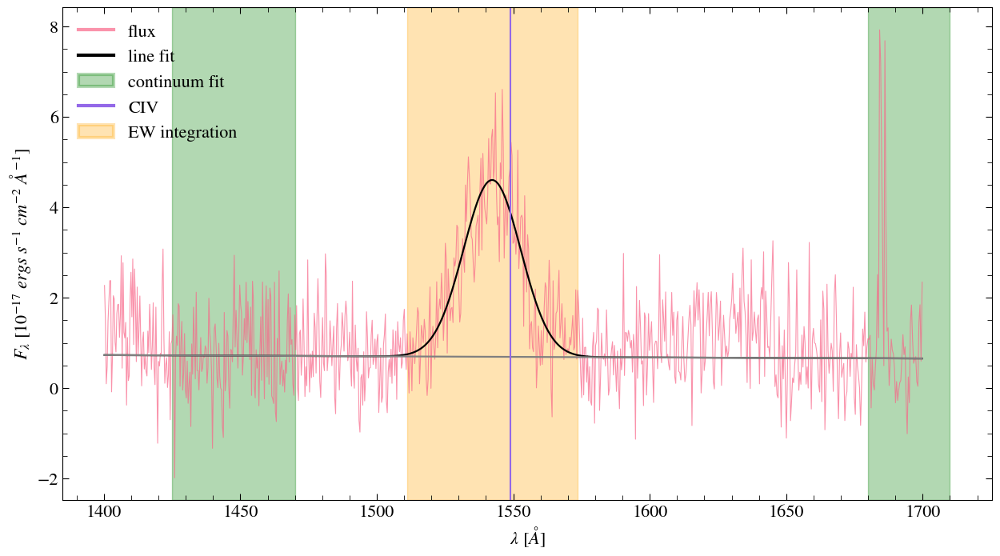


                SDSS: 000610.67+121501.2
                FWHM: 4775.437 vs 4540.061 (Hamann)
                REW: 152.727 vs 106.997 (Hamann)
                kt80: 0.372 vs 0.372 (Hamann)
    
ValueError in get_absorption_interval()


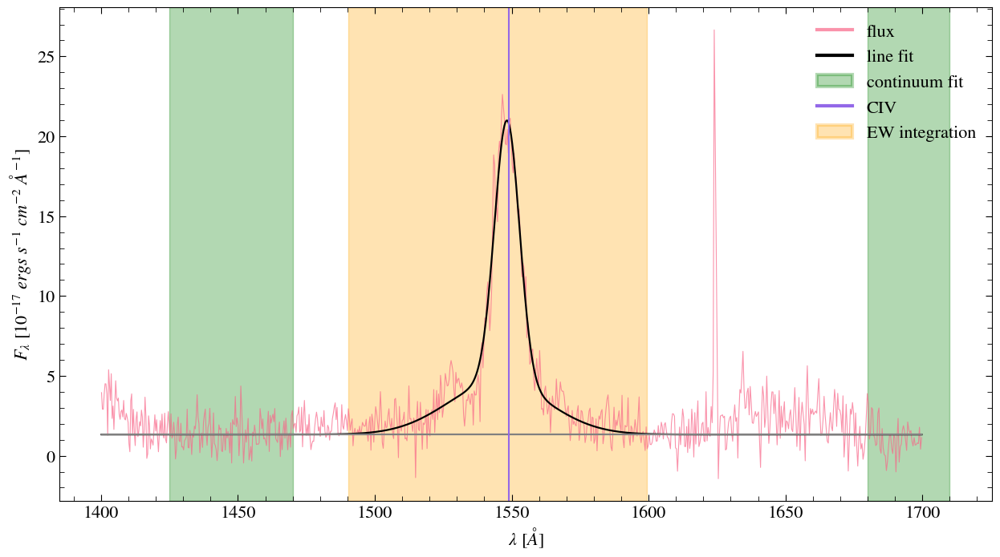


                SDSS: 000746.19+122223.9
                FWHM: 2351.669 vs 2432.83 (Hamann)
                REW: 266.456 vs 219.634 (Hamann)
                kt80: 0.319 vs 0.284 (Hamann)
    


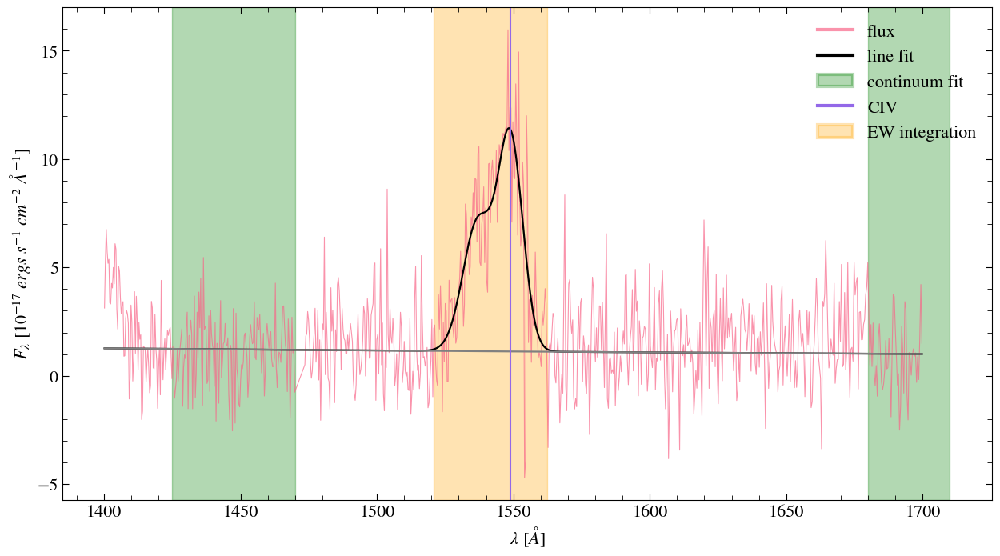


                SDSS: 002400.25+245031.9
                FWHM: 3884.666 vs 3523.282 (Hamann)
                REW: 169.857 vs 143.69 (Hamann)
                kt80: 0.259 vs 0.372 (Hamann)
    


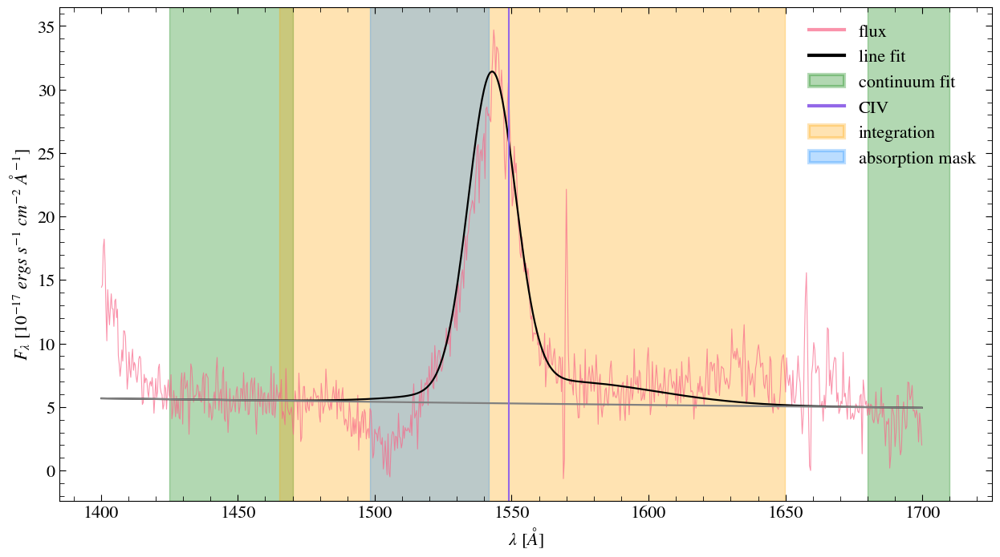


                SDSS: 004713.21+264024.7
                FWHM: 4062.331 vs 3685.428 (Hamann)
                REW: 123.567 vs 100.506 (Hamann)
                kt80: 0.358 vs 0.325 (Hamann)
    


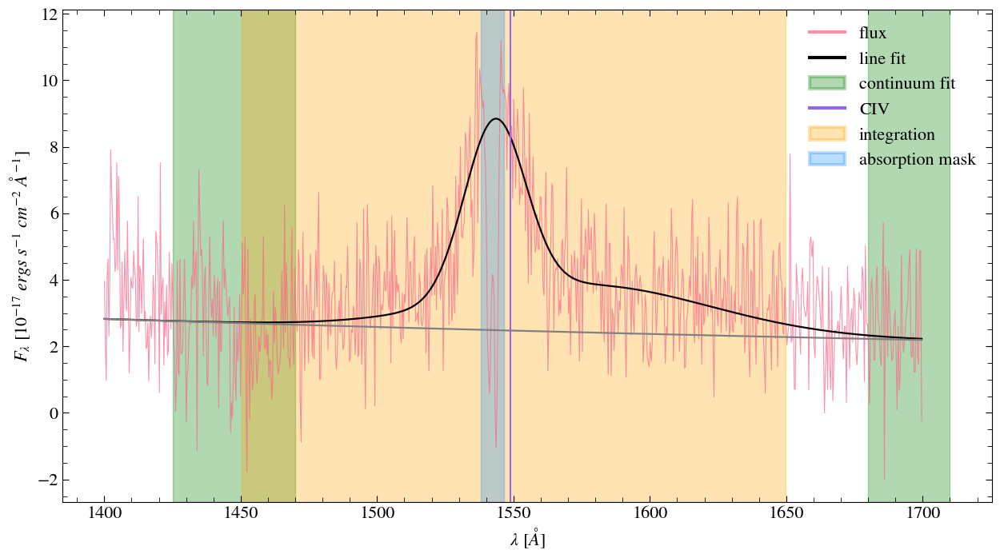


                SDSS: 005044.95-021217.6
                FWHM: 5856.408 vs 4343.058 (Hamann)
                REW: 118.196 vs 147.225 (Hamann)
                kt80: 0.209 vs 0.193 (Hamann)
    


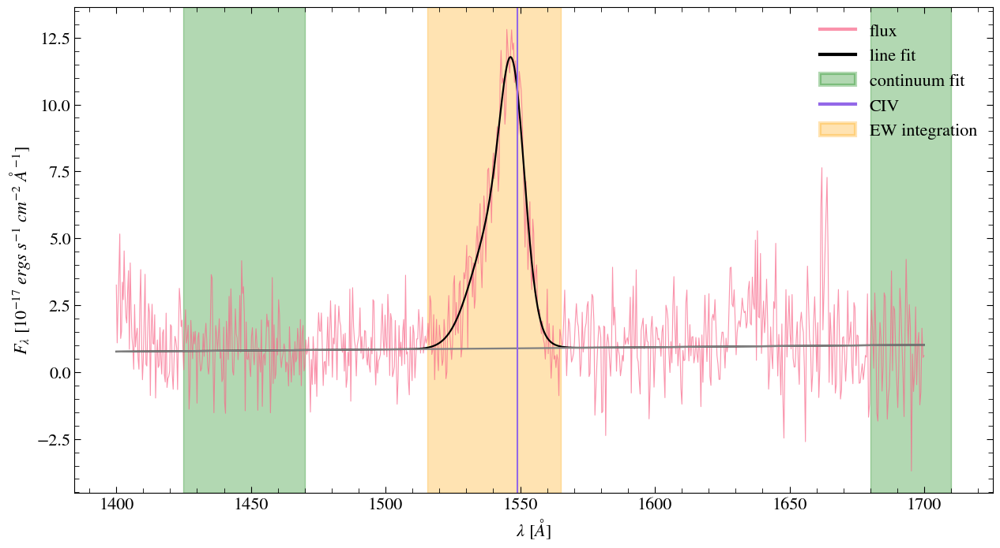


                SDSS: 005233.24-055653.5
                FWHM: 2696.562 vs 2450.95 (Hamann)
                REW: 204.116 vs 188.145 (Hamann)
                kt80: 0.288 vs 0.274 (Hamann)
    


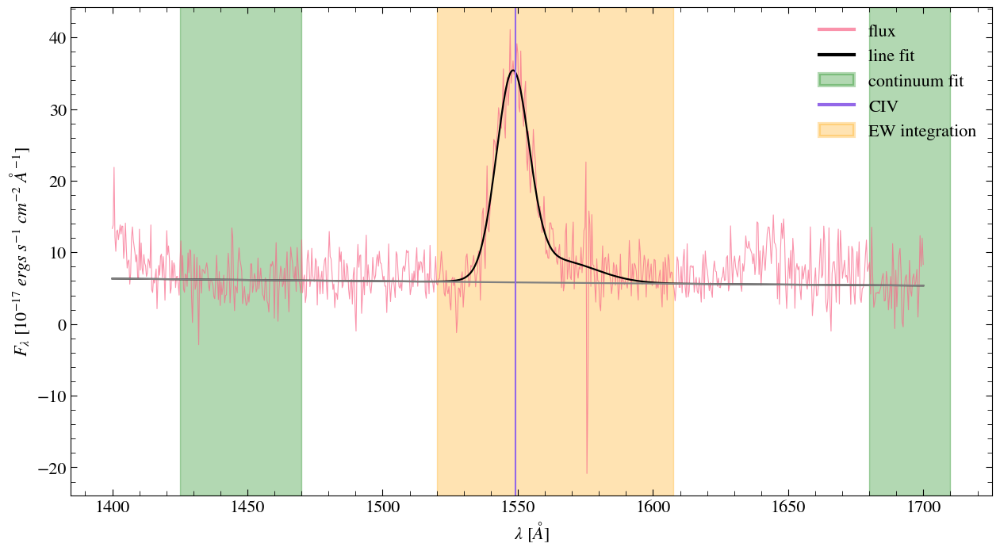


                SDSS: 014111.13-031852.5
                FWHM: 2866.075 vs 2985.648 (Hamann)
                REW: 97.224 vs 101.008 (Hamann)
                kt80: 0.35 vs 0.372 (Hamann)
    


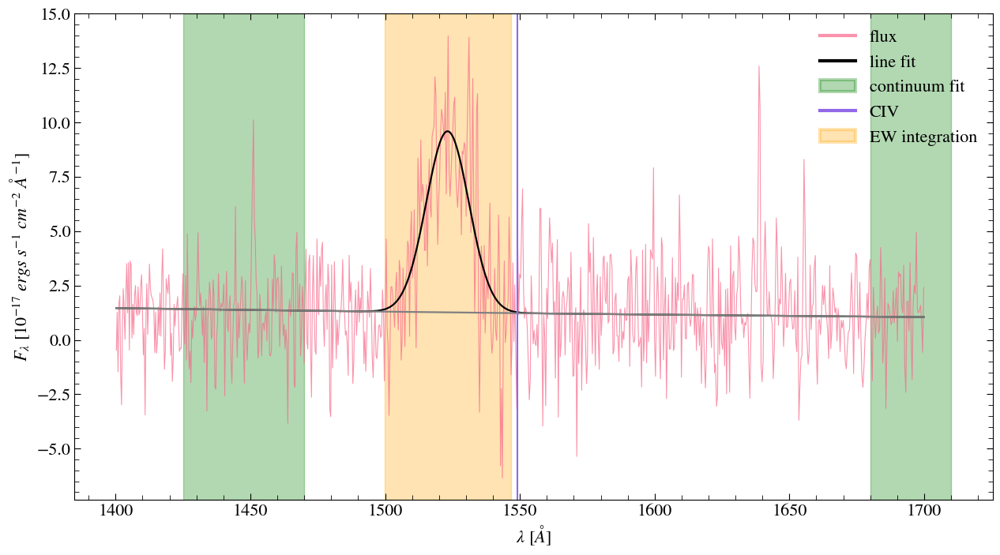


                SDSS: 015222.58+323152.7
                FWHM: 3606.383 vs 3677.216 (Hamann)
                REW: 132.2 vs 135.549 (Hamann)
                kt80: 0.372 vs 0.368 (Hamann)
    


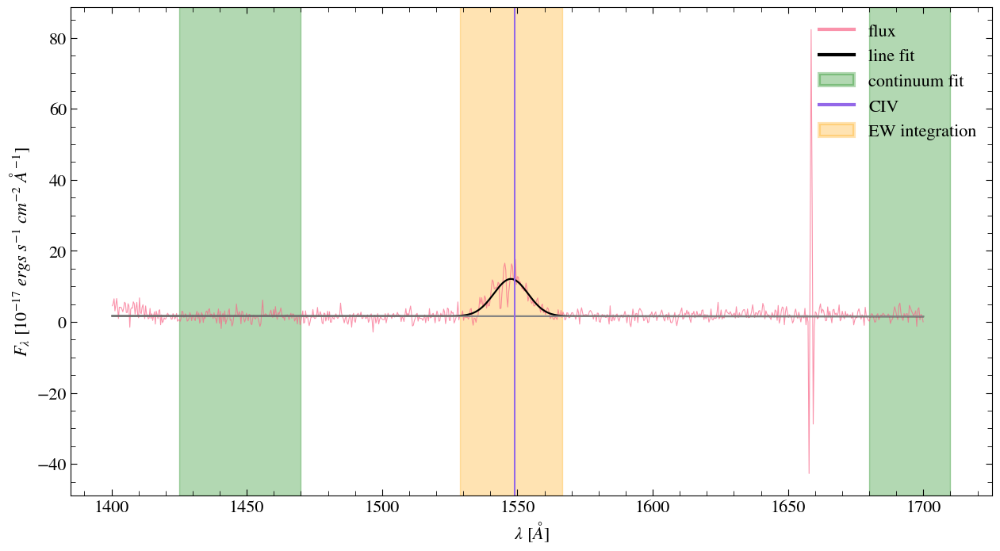


                SDSS: 020932.15+312202.7
                FWHM: 2872.032 vs 2180.064 (Hamann)
                REW: 103.289 vs 107.677 (Hamann)
                kt80: 0.372 vs 0.345 (Hamann)
    


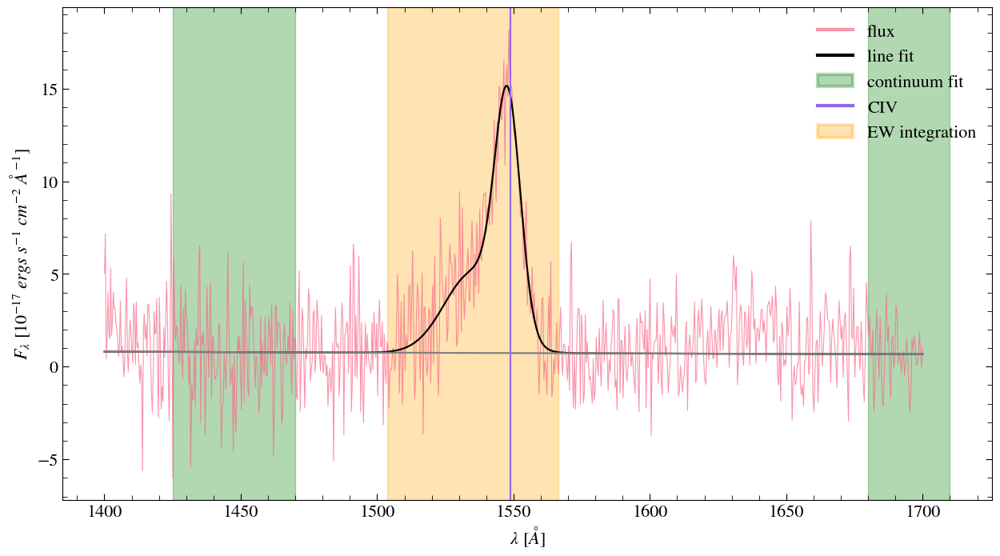


                SDSS: 022052.11+013711.1
                FWHM: 2500.197 vs 2613.405 (Hamann)
                REW: 356.076 vs 328.394 (Hamann)
                kt80: 0.226 vs 0.219 (Hamann)
    


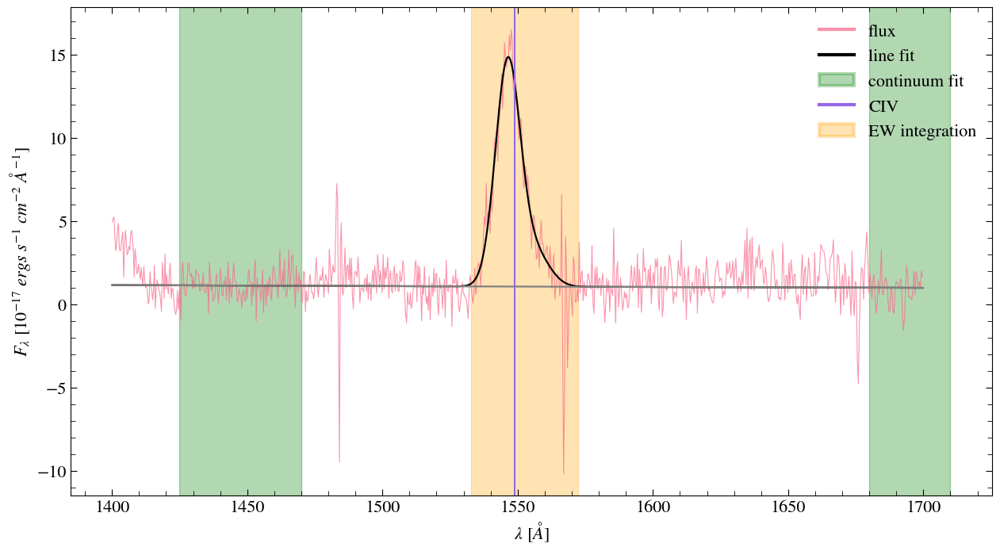


                SDSS: 080425.75+470159.0
                FWHM: 2230.12 vs 2371.301 (Hamann)
                REW: 167.5 vs 161.559 (Hamann)
                kt80: 0.337 vs 0.347 (Hamann)
    


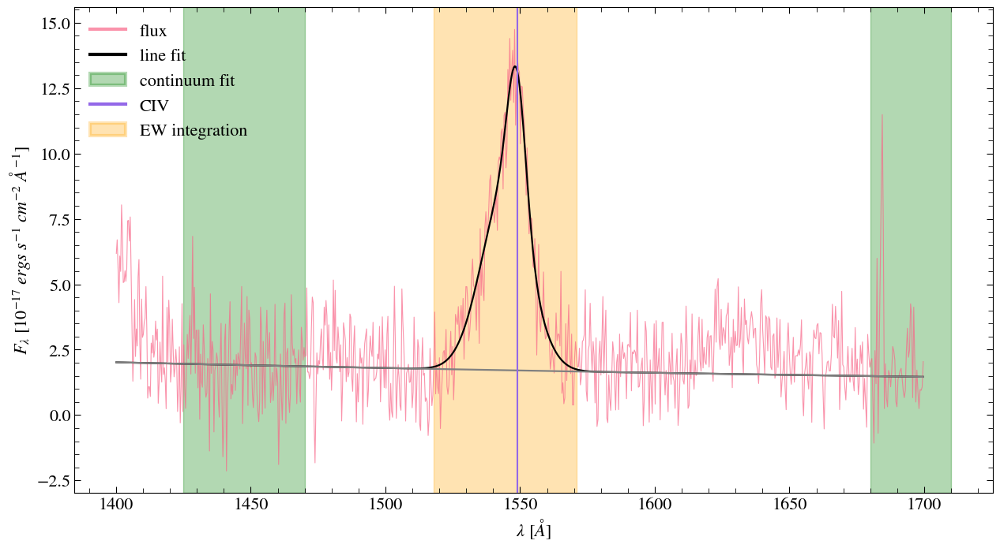


                SDSS: 080547.66+454159.0
                FWHM: 2809.941 vs 2667.071 (Hamann)
                REW: 115.894 vs 108.69 (Hamann)
                kt80: 0.254 vs 0.211 (Hamann)
    


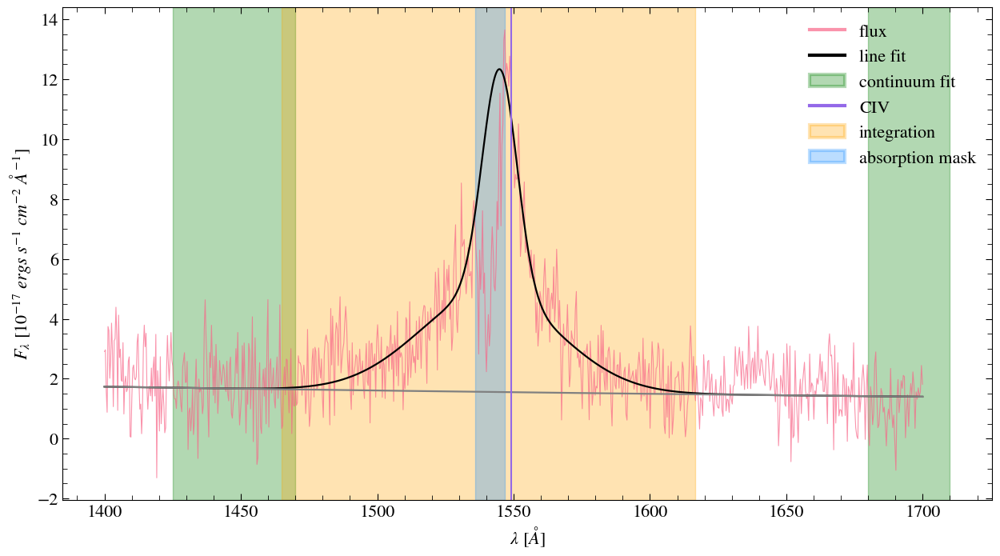


                SDSS: 082536.31+200040.3
                FWHM: 3743.495 vs 3265.175 (Hamann)
                REW: 190.041 vs 210.805 (Hamann)
                kt80: 0.216 vs 0.171 (Hamann)
    


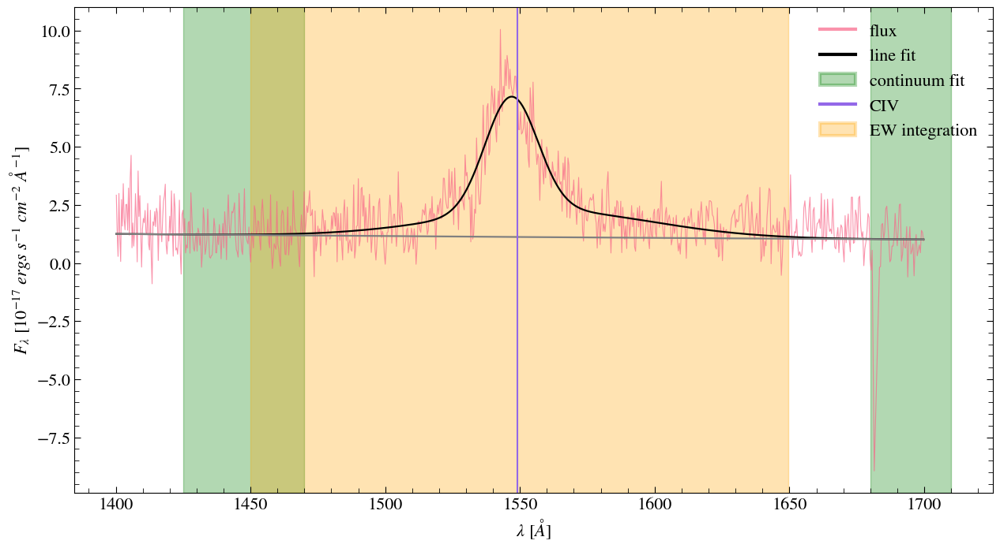


                SDSS: 082649.30+163945.2
                FWHM: 5110.798 vs 5633.199 (Hamann)
                REW: 222.196 vs 204.888 (Hamann)
                kt80: 0.302 vs 0.33 (Hamann)
    


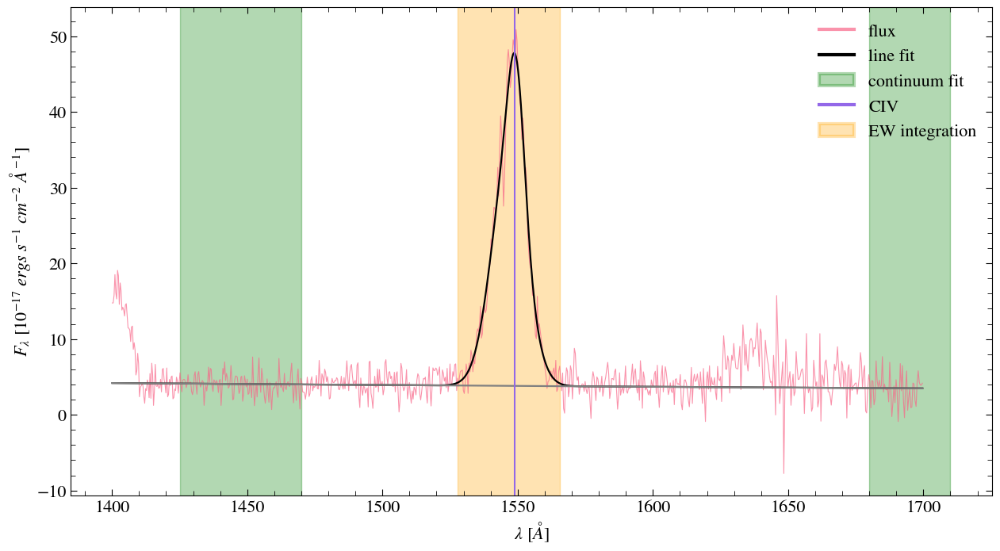


                SDSS: 082653.42+054247.3
                FWHM: 2351.839 vs 2433.822 (Hamann)
                REW: 156.291 vs 204.619 (Hamann)
                kt80: 0.306 vs 0.358 (Hamann)
    


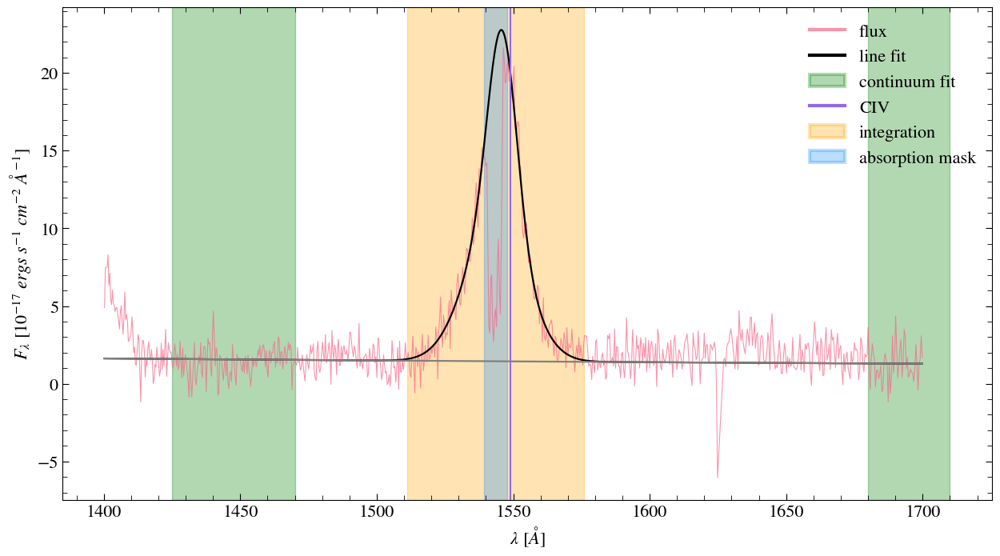


                SDSS: 083200.20+161500.3
                FWHM: 3108.137 vs 3082.076 (Hamann)
                REW: 223.05 vs 300.478 (Hamann)
                kt80: 0.305 vs 0.329 (Hamann)
    


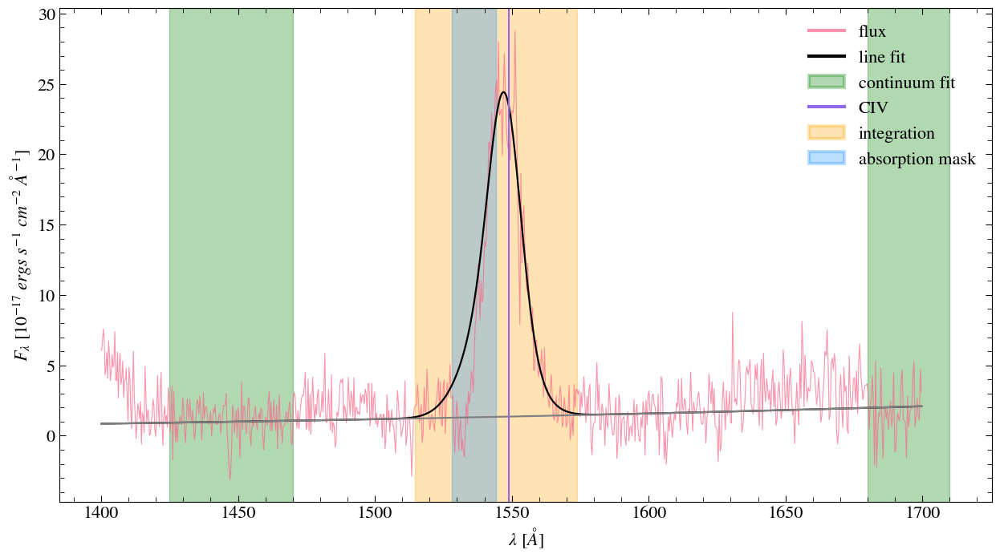


                SDSS: 083448.48+015921.1
                FWHM: 3106.572 vs 2863.092 (Hamann)
                REW: 280.17 vs 209.44 (Hamann)
                kt80: 0.332 vs 0.365 (Hamann)
    


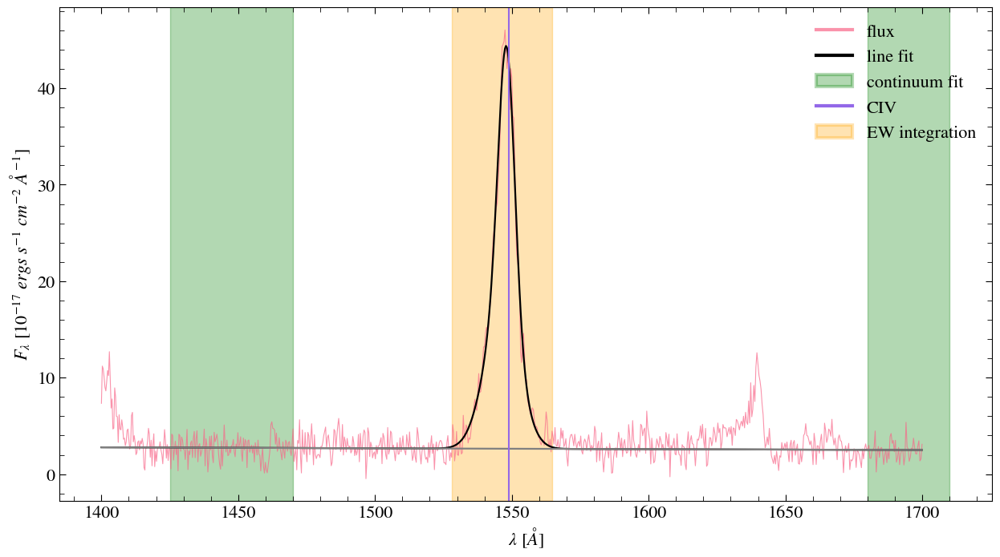


                SDSS: 084447.66+462338.7
                FWHM: 1692.043 vs 1656.003 (Hamann)
                REW: 165.672 vs 160.601 (Hamann)
                kt80: 0.312 vs 0.346 (Hamann)
    


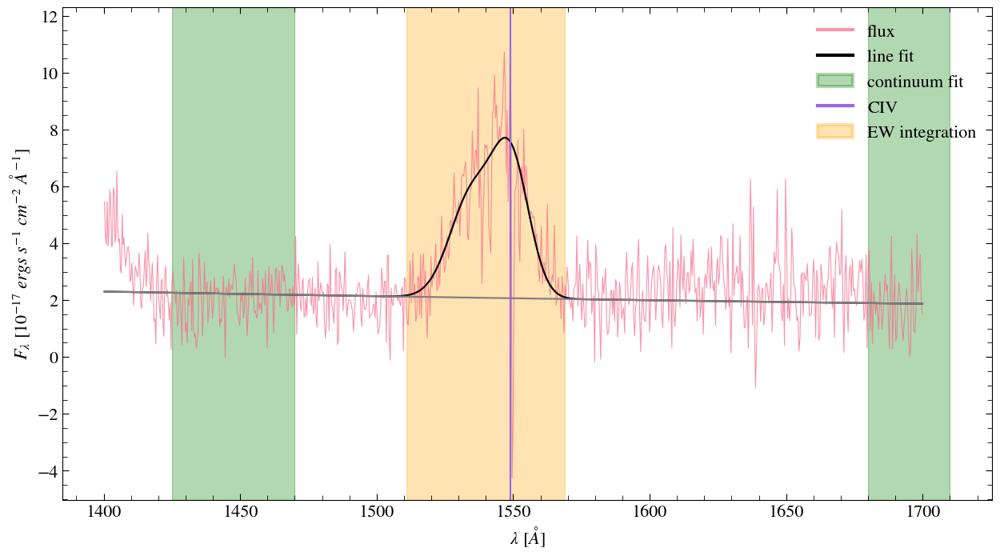


                SDSS: 085451.11+173009.1
                FWHM: 5251.303 vs 4199.357 (Hamann)
                REW: 73.168 vs 120.014 (Hamann)
                kt80: 0.376 vs 0.37 (Hamann)
    


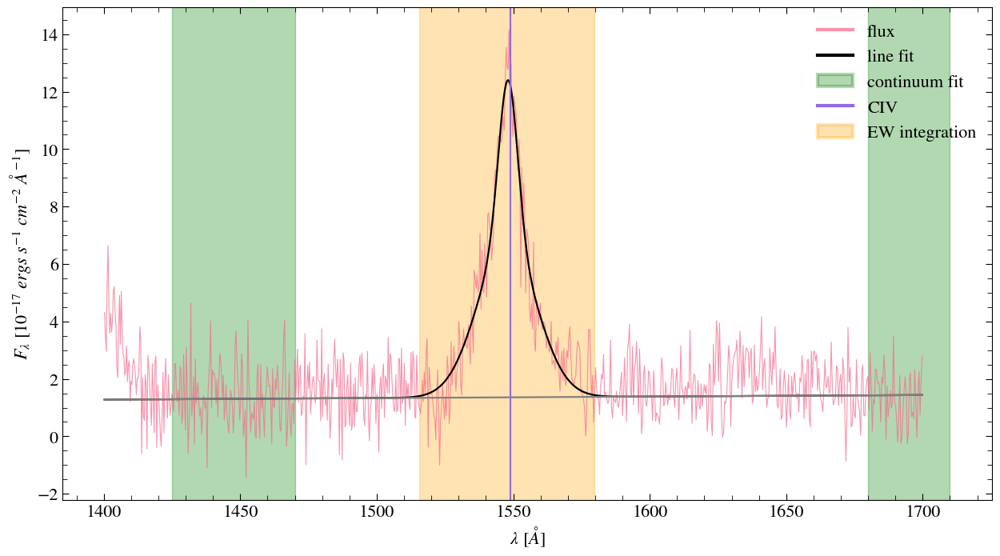


                SDSS: 090306.18+234909.8
                FWHM: 2467.523 vs 2480.755 (Hamann)
                REW: 143.762 vs 143.591 (Hamann)
                kt80: 0.223 vs 0.209 (Hamann)
    


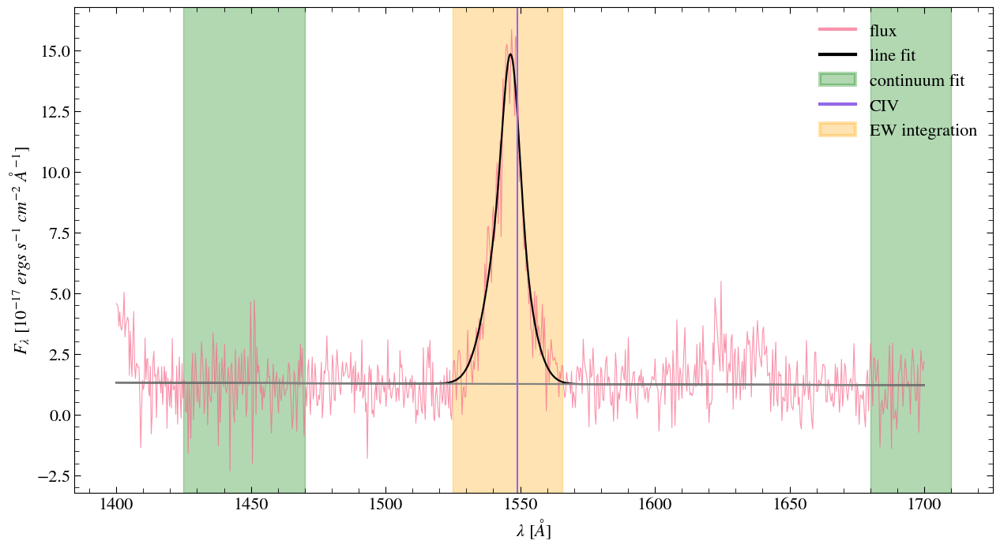


                SDSS: 091303.90+234435.2
                FWHM: 2051.079 vs 2190.262 (Hamann)
                REW: 140.223 vs 144.743 (Hamann)
                kt80: 0.282 vs 0.34 (Hamann)
    


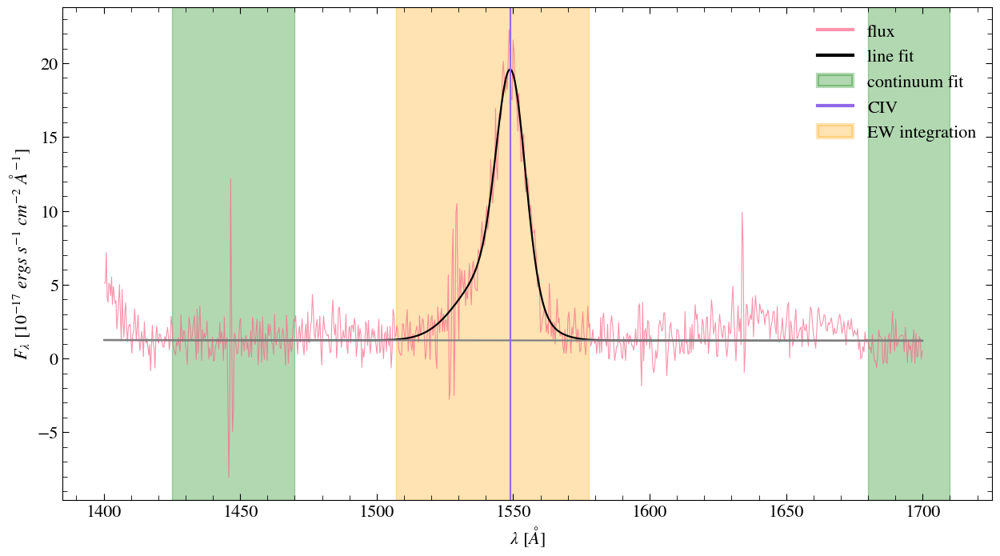


                SDSS: 091508.45+561316.0
                FWHM: 2787.096 vs 2867.477 (Hamann)
                REW: 272.361 vs 225.875 (Hamann)
                kt80: 0.3 vs 0.355 (Hamann)
    


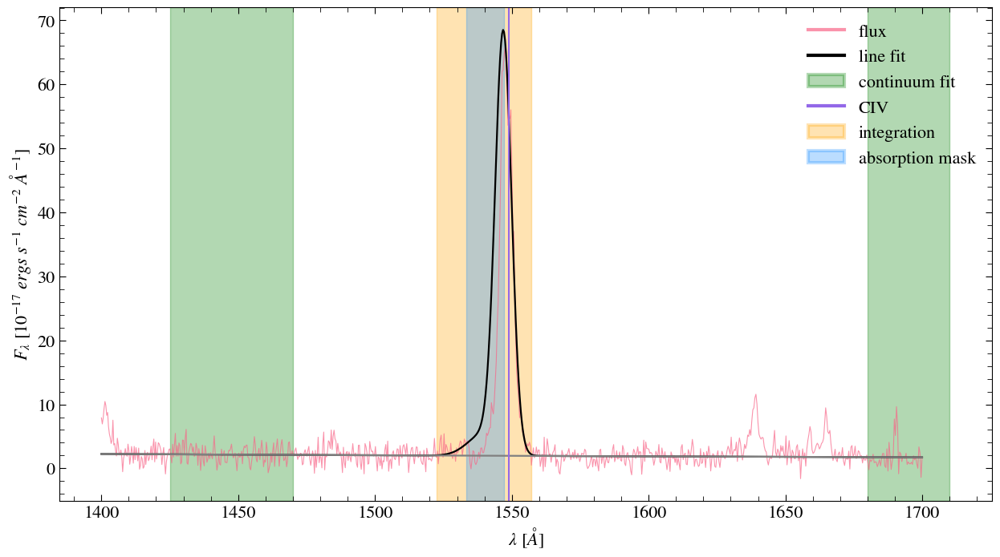


                SDSS: 092049.59+282200.9
                FWHM: 1396.469 vs 1048.141 (Hamann)
                REW: 195.62 vs 197.255 (Hamann)
                kt80: 0.363 vs 0.367 (Hamann)
    


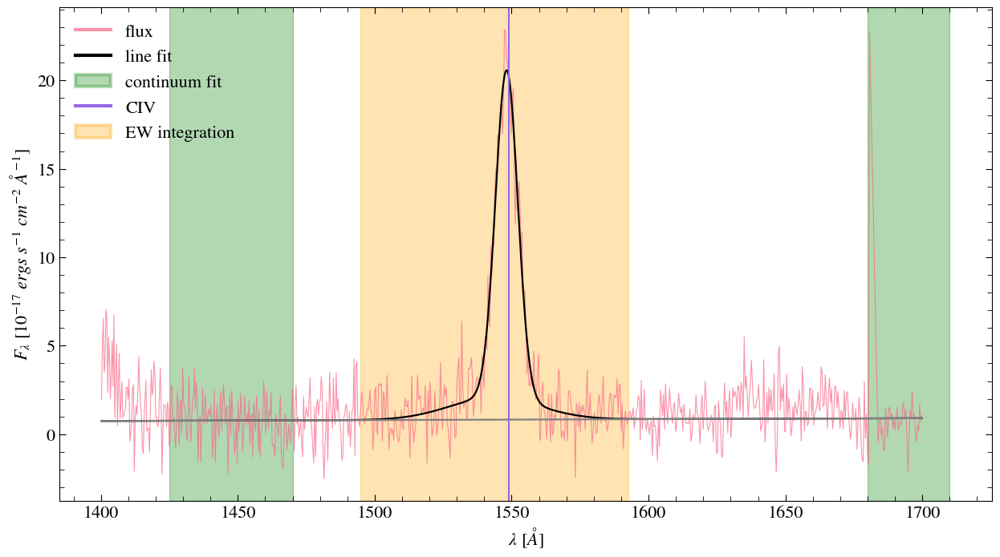


                SDSS: 093226.93+461442.8
                FWHM: 1940.662 vs 1960.054 (Hamann)
                REW: 308.678 vs 443.04 (Hamann)
                kt80: 0.357 vs 0.347 (Hamann)
    


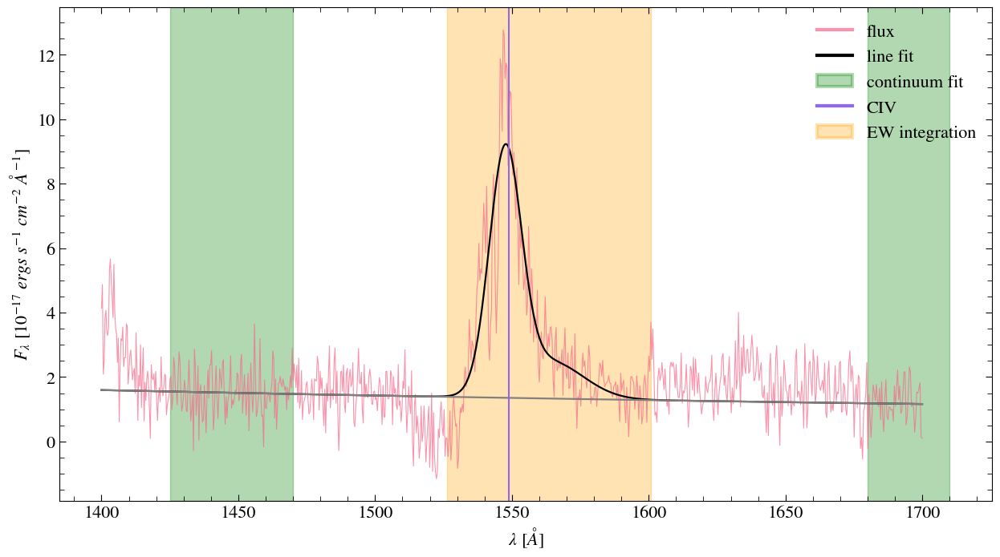


                SDSS: 093506.96-024137.7
                FWHM: 2847.911 vs 2404.04 (Hamann)
                REW: 110.316 vs 119.496 (Hamann)
                kt80: 0.334 vs 0.249 (Hamann)
    


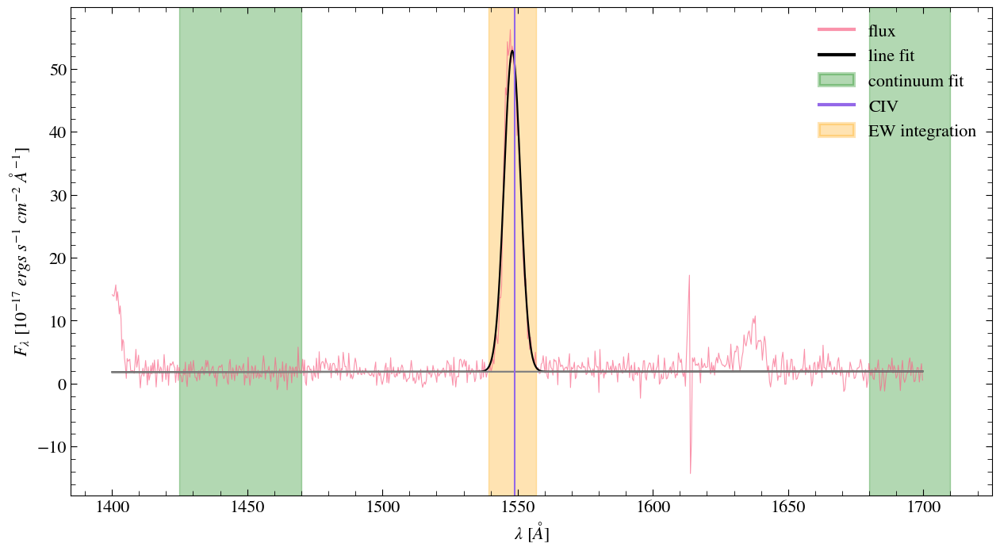


                SDSS: 093638.41+101930.3
                FWHM: 1367.03 vs 1271.195 (Hamann)
                REW: 199.337 vs 171.815 (Hamann)
                kt80: 0.371 vs 0.37 (Hamann)
    


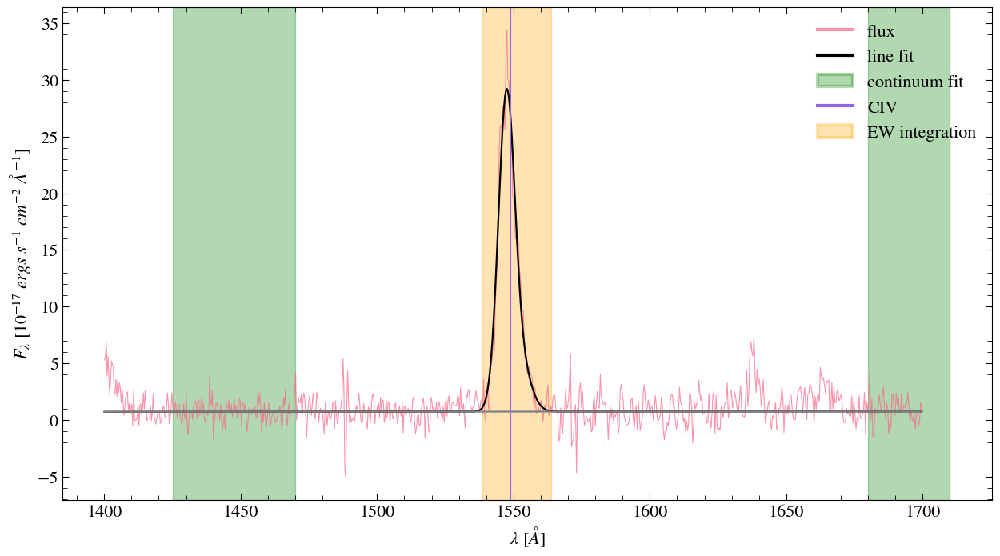


                SDSS: 095033.51+211729.1
                FWHM: 1452.044 vs 1387.112 (Hamann)
                REW: 322.039 vs 272.256 (Hamann)
                kt80: 0.35 vs 0.361 (Hamann)
    


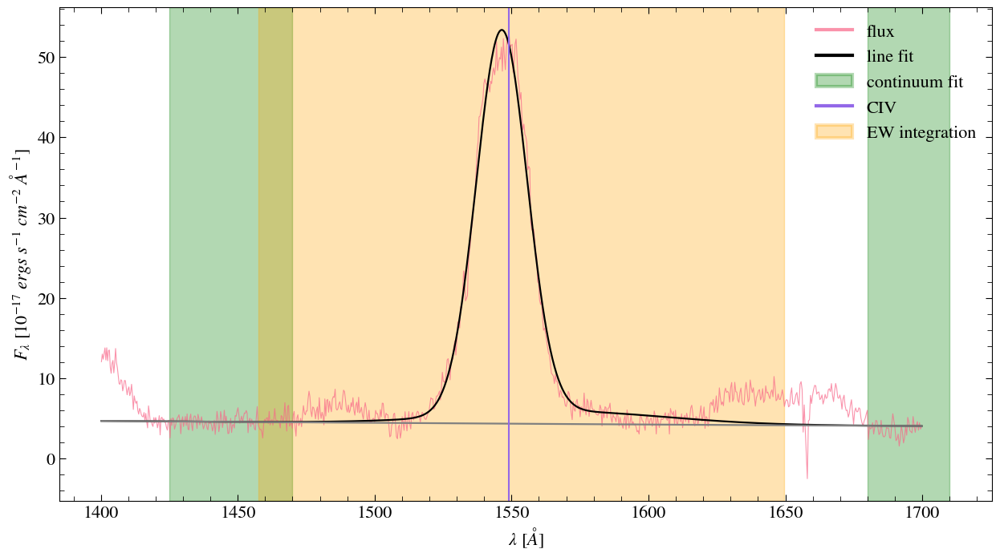


                SDSS: 095823.14+500018.1
                FWHM: 4317.315 vs 4344.558 (Hamann)
                REW: 317.018 vs 262.82 (Hamann)
                kt80: 0.366 vs 0.367 (Hamann)
    


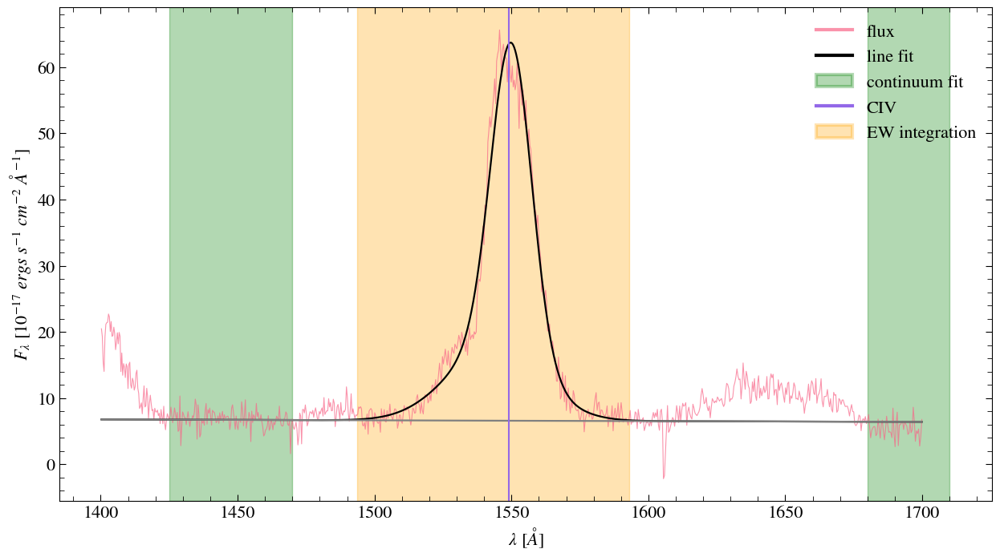


                SDSS: 101324.53+342702.6
                FWHM: 3782.277 vs 4157.047 (Hamann)
                REW: 204.297 vs 204.531 (Hamann)
                kt80: 0.334 vs 0.344 (Hamann)
    


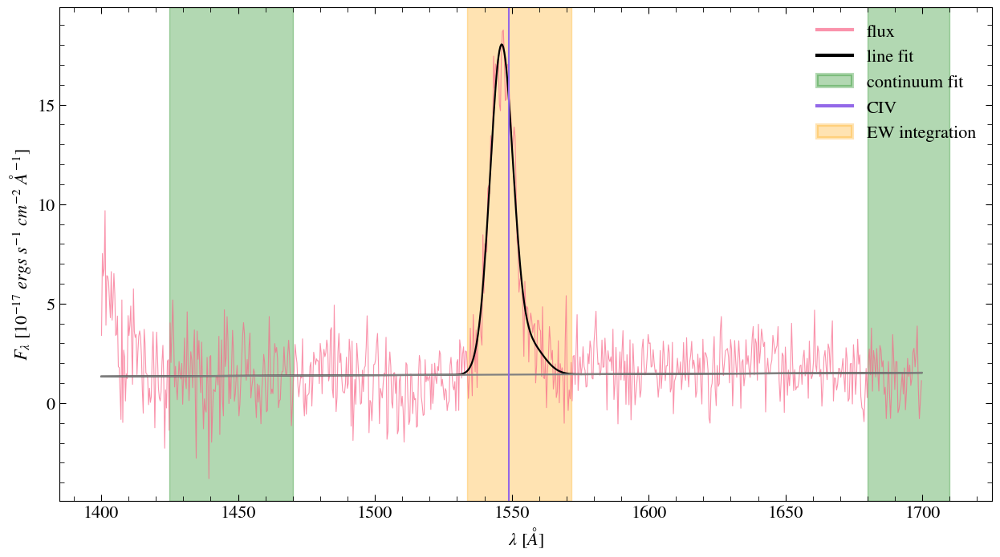


                SDSS: 101533.65+631752.6
                FWHM: 1970.836 vs 2011.595 (Hamann)
                REW: 133.382 vs 129.997 (Hamann)
                kt80: 0.355 vs 0.361 (Hamann)
    


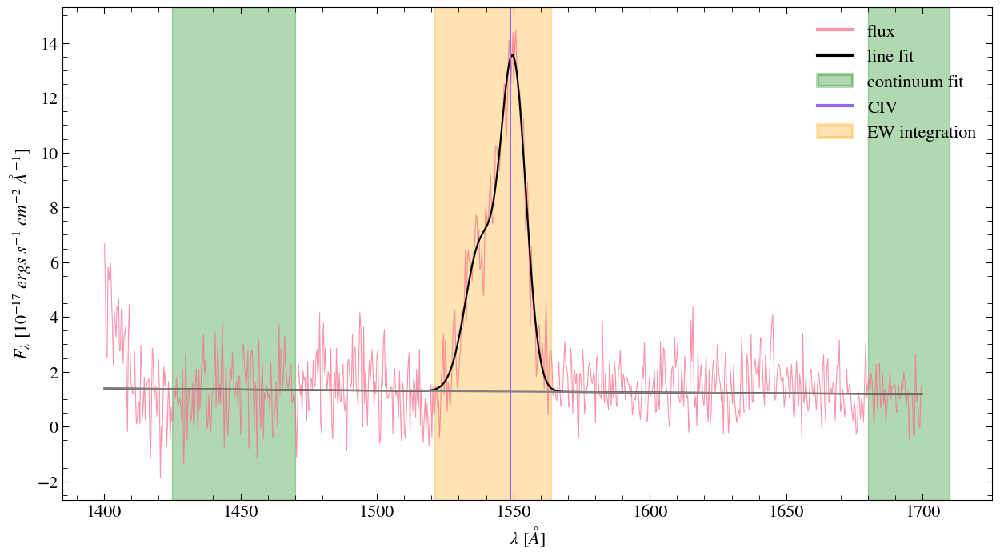


                SDSS: 102130.74+214438.4
                FWHM: 2829.436 vs 3566.695 (Hamann)
                REW: 164.902 vs 155.466 (Hamann)
                kt80: 0.255 vs 0.372 (Hamann)
    


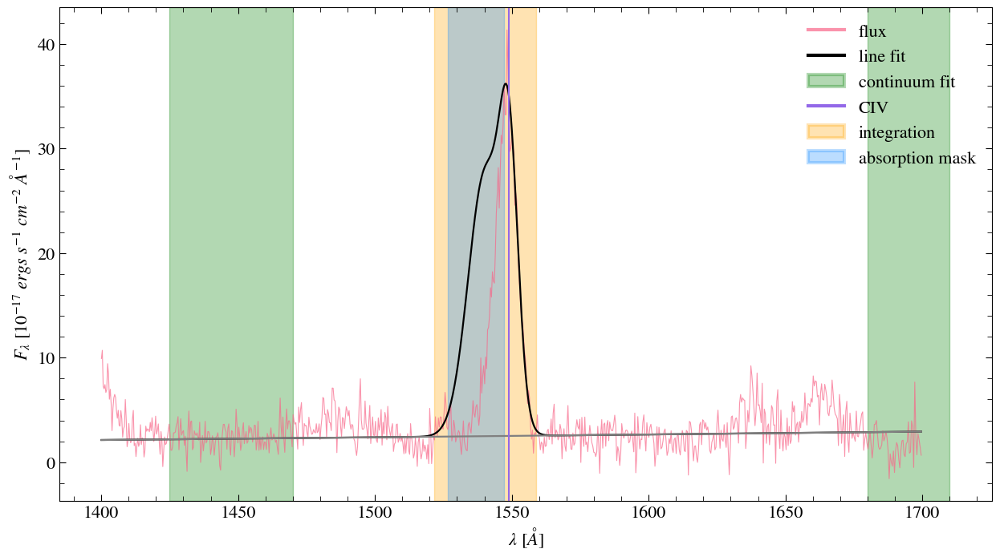


                SDSS: 102353.44+580004.9
                FWHM: 3436.222 vs 2107.266 (Hamann)
                REW: 134.429 vs 116.39 (Hamann)
                kt80: 0.333 vs 0.372 (Hamann)
    


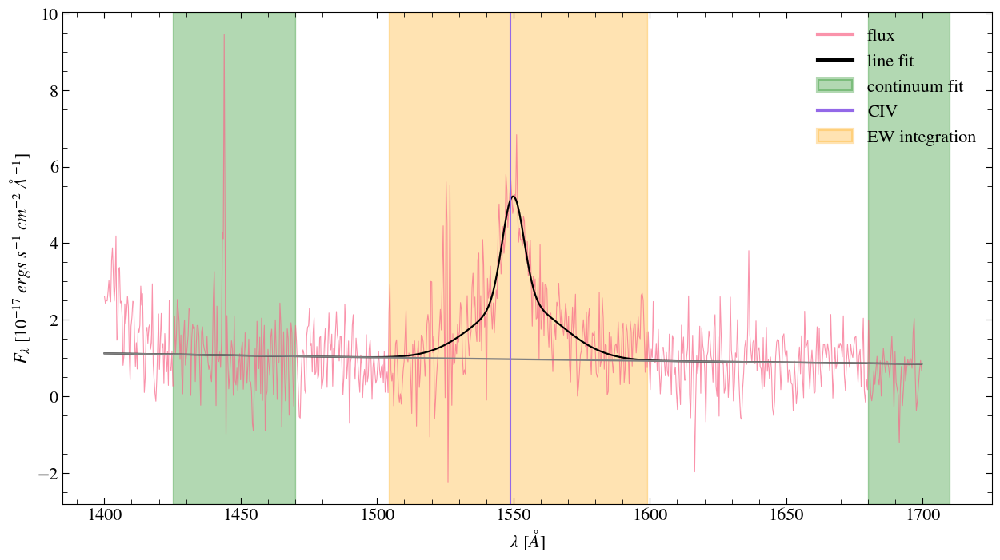


                SDSS: 102447.32-013633.8
                FWHM: 2455.797 vs 2843.202 (Hamann)
                REW: 94.643 vs 192.349 (Hamann)
                kt80: 0.199 vs 0.148 (Hamann)
    


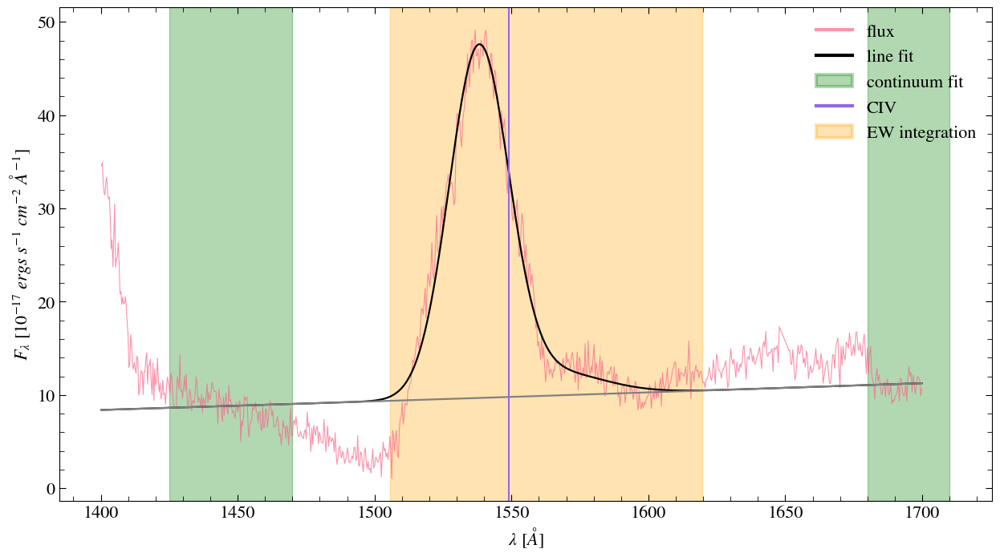


                SDSS: 102541.78+245424.2
                FWHM: 5088.172 vs 5324.386 (Hamann)
                REW: 117.04 vs 114.538 (Hamann)
                kt80: 0.361 vs 0.365 (Hamann)
    


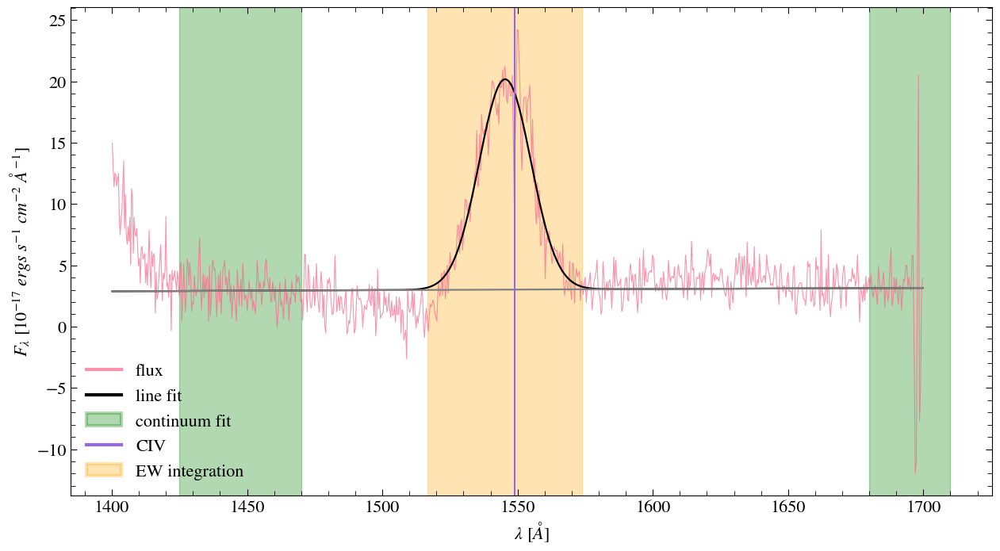


                SDSS: 103146.53+290324.1
                FWHM: 4366.665 vs 4363.774 (Hamann)
                REW: 135.047 vs 120.767 (Hamann)
                kt80: 0.372 vs 0.372 (Hamann)
    


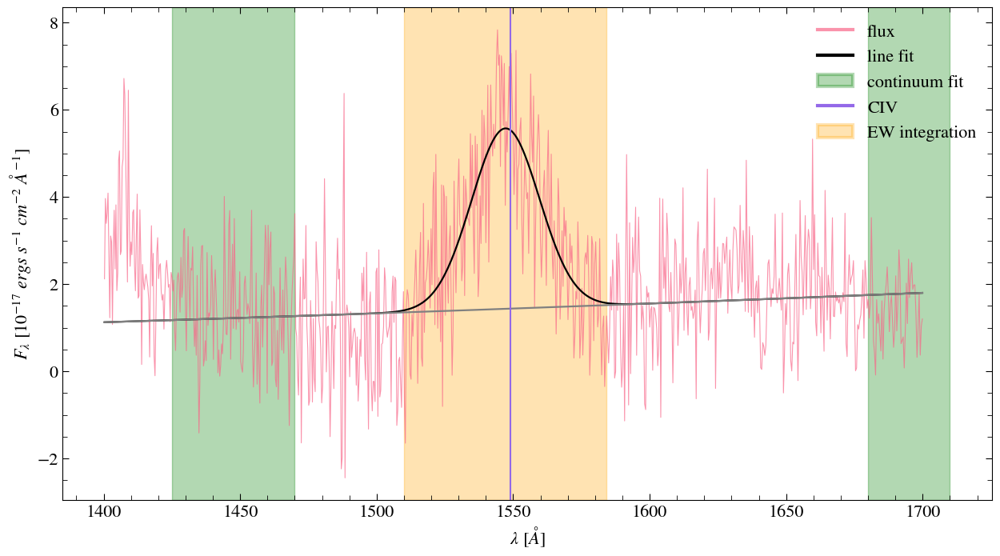


                SDSS: 103456.95+143012.5
                FWHM: 5663.715 vs 5949.083 (Hamann)
                REW: 91.169 vs 102.341 (Hamann)
                kt80: 0.372 vs 0.372 (Hamann)
    


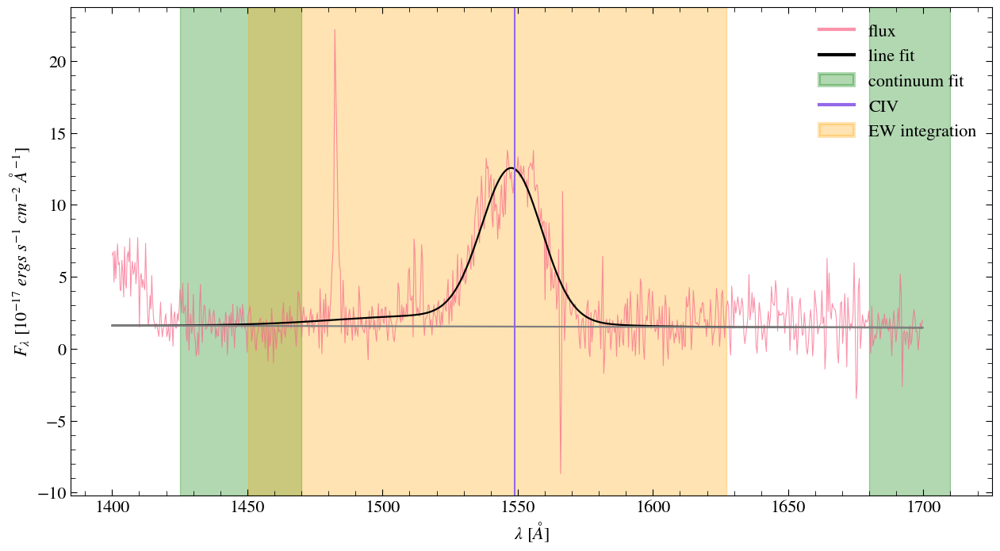


                SDSS: 104611.50+024351.6
                FWHM: 5229.922 vs 4854.269 (Hamann)
                REW: 241.177 vs 217.582 (Hamann)
                kt80: 0.359 vs 0.354 (Hamann)
    


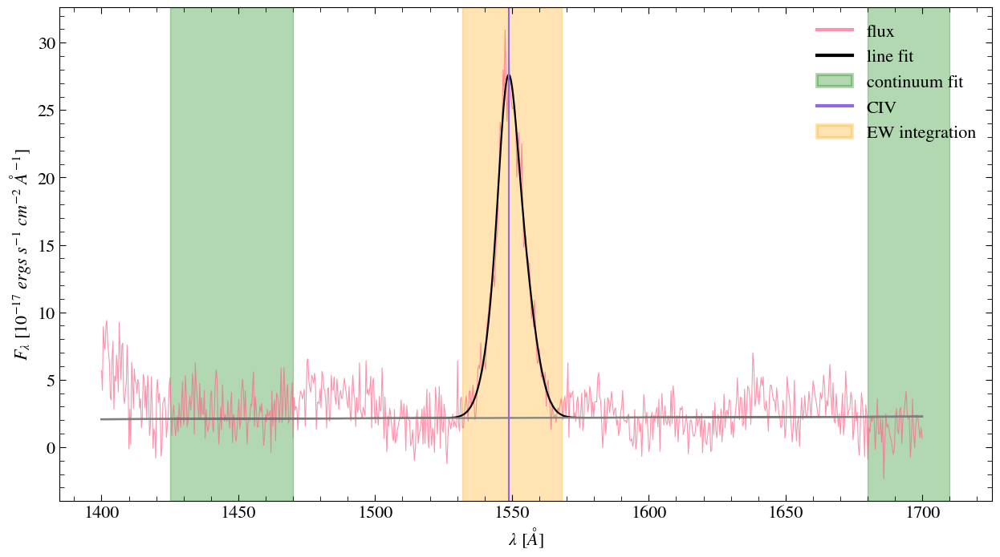


                SDSS: 104718.35+484433.8
                FWHM: 2216.377 vs 2521.46 (Hamann)
                REW: 152.387 vs 158.03 (Hamann)
                kt80: 0.311 vs 0.361 (Hamann)
    


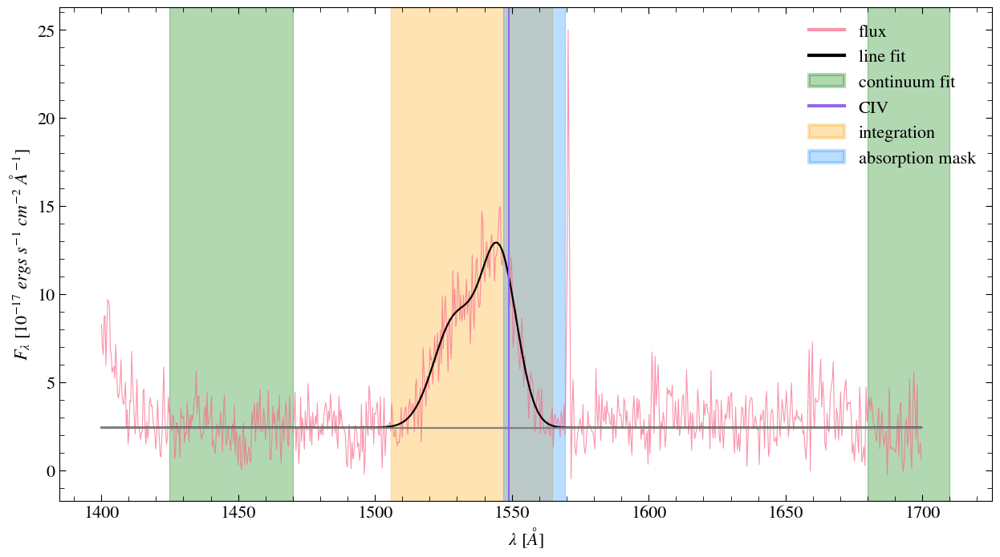


                SDSS: 104754.58+621300.5
                FWHM: 5360.713 vs 5080.835 (Hamann)
                REW: 113.016 vs 104.956 (Hamann)
                kt80: 0.284 vs 0.372 (Hamann)
    
ValueError in get_absorption_interval()


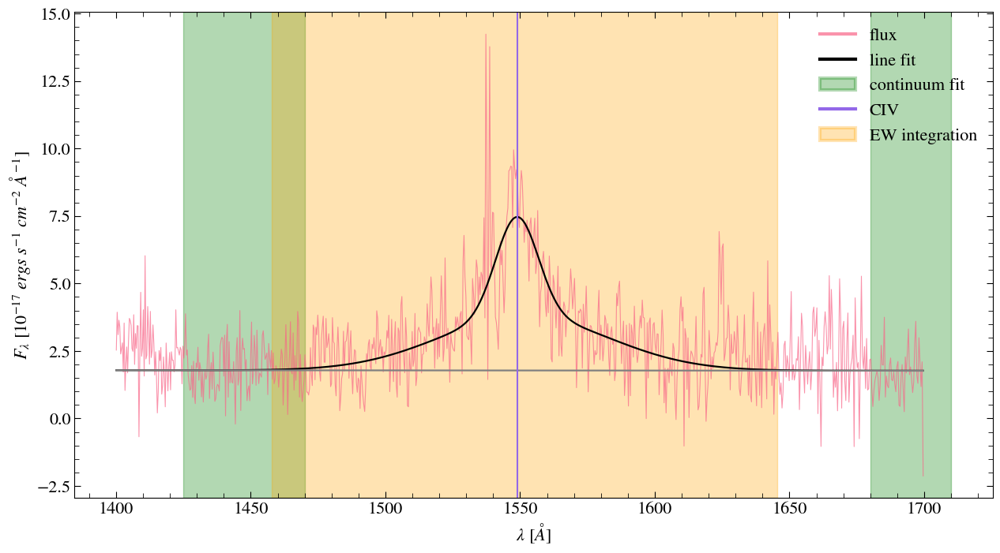


                SDSS: 110202.68-000752.7
                FWHM: 4896.559 vs 3766.854 (Hamann)
                REW: 147.74 vs 120.732 (Hamann)
                kt80: 0.197 vs 0.179 (Hamann)
    


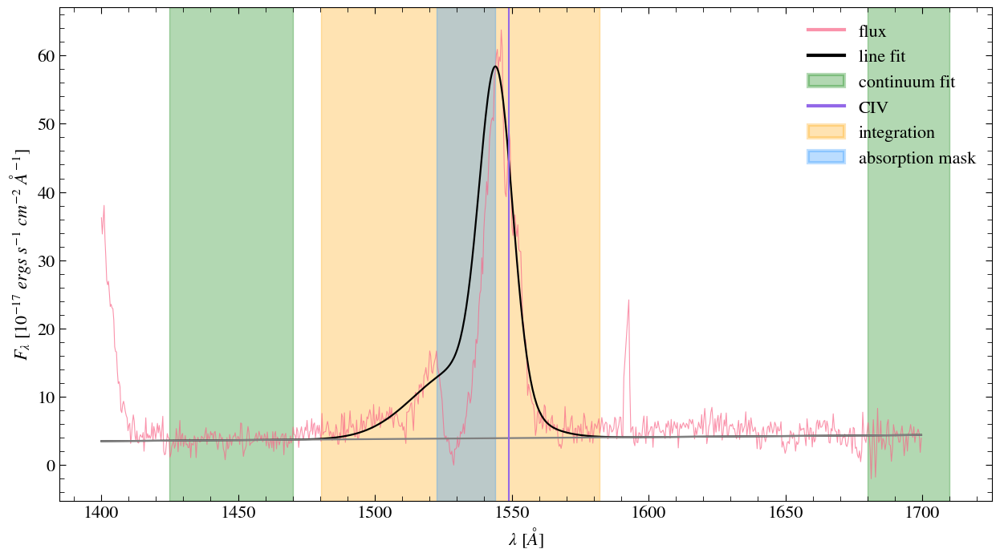


                SDSS: 111017.13+193012.5
                FWHM: 3061.676 vs 2427.165 (Hamann)
                REW: 230.136 vs 219.75 (Hamann)
                kt80: 0.308 vs 0.332 (Hamann)
    


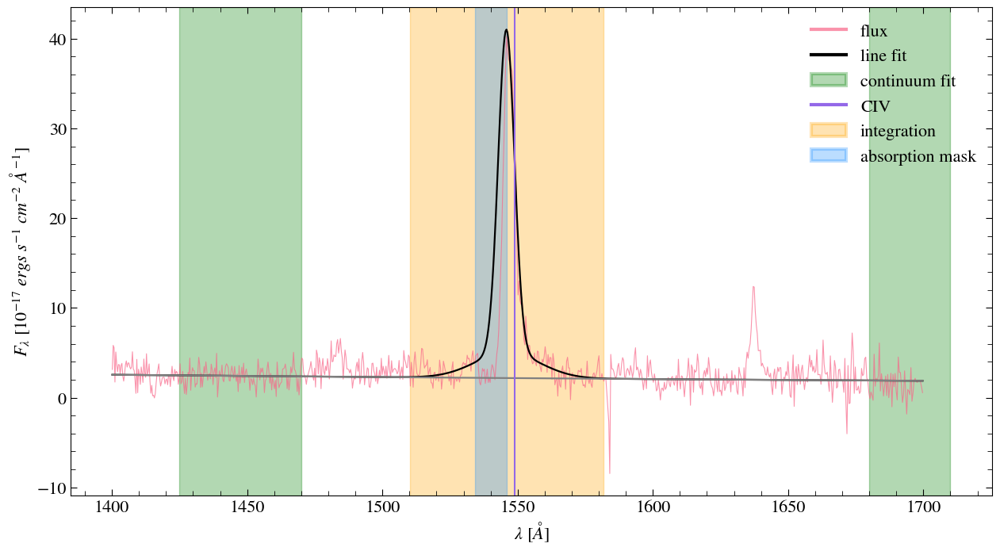


                SDSS: 111346.10+185451.9
                FWHM: 1438.322 vs 985.843 (Hamann)
                REW: 120.878 vs 126.613 (Hamann)
                kt80: 0.354 vs 0.351 (Hamann)
    


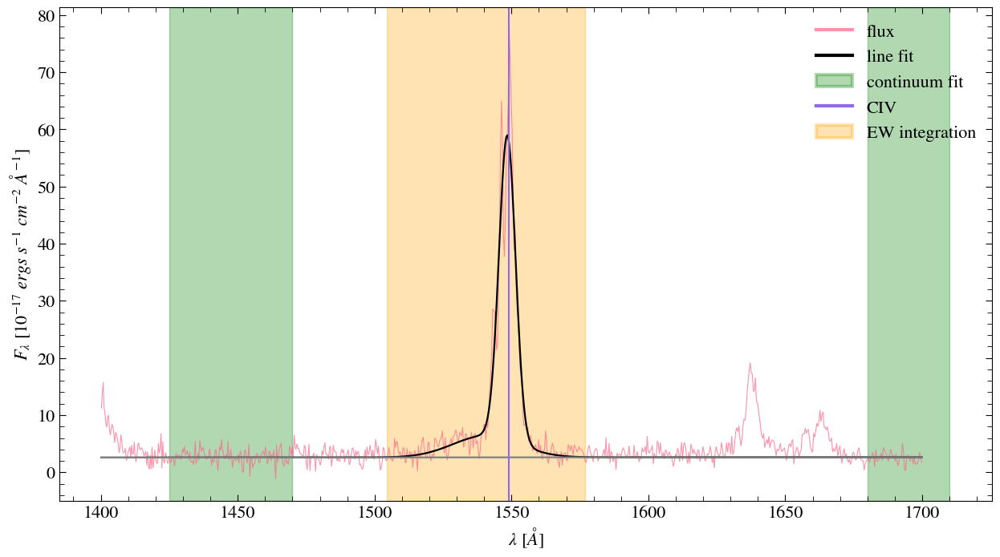


                SDSS: 111355.72+451452.6
                FWHM: 1434.272 vs 1243.226 (Hamann)
                REW: 211.753 vs 190.171 (Hamann)
                kt80: 0.357 vs 0.351 (Hamann)
    


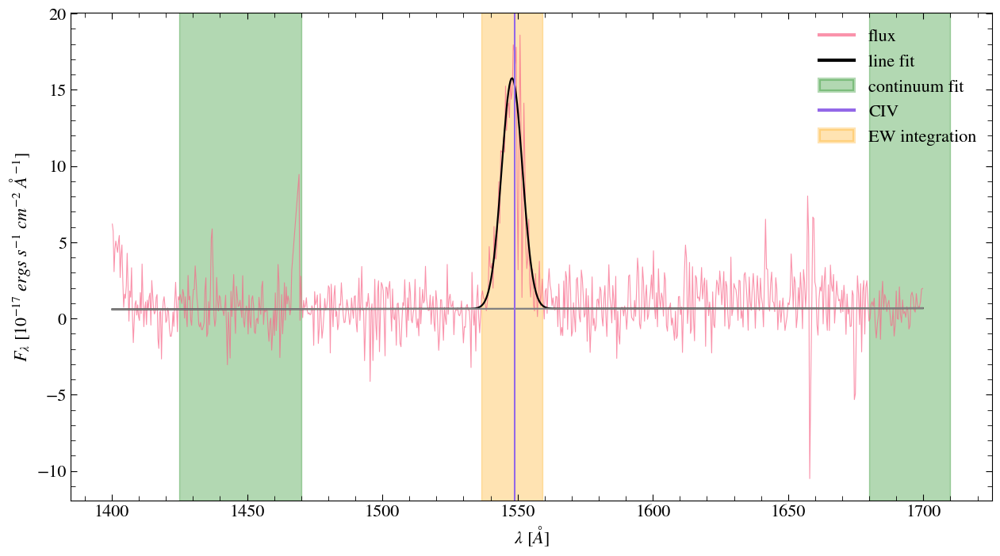


                SDSS: 111516.33+194950.4
                FWHM: 1751.644 vs 1739.004 (Hamann)
                REW: 221.939 vs 246.593 (Hamann)
                kt80: 0.372 vs 0.363 (Hamann)
    


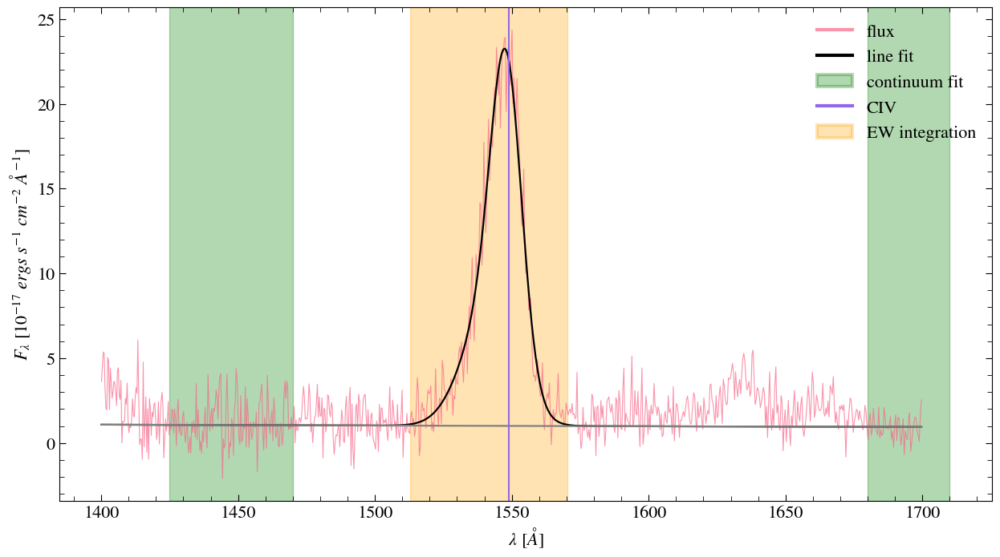


                SDSS: 111729.56+462331.2
                FWHM: 2998.252 vs 3052.827 (Hamann)
                REW: 400.958 vs 395.287 (Hamann)
                kt80: 0.326 vs 0.348 (Hamann)
    


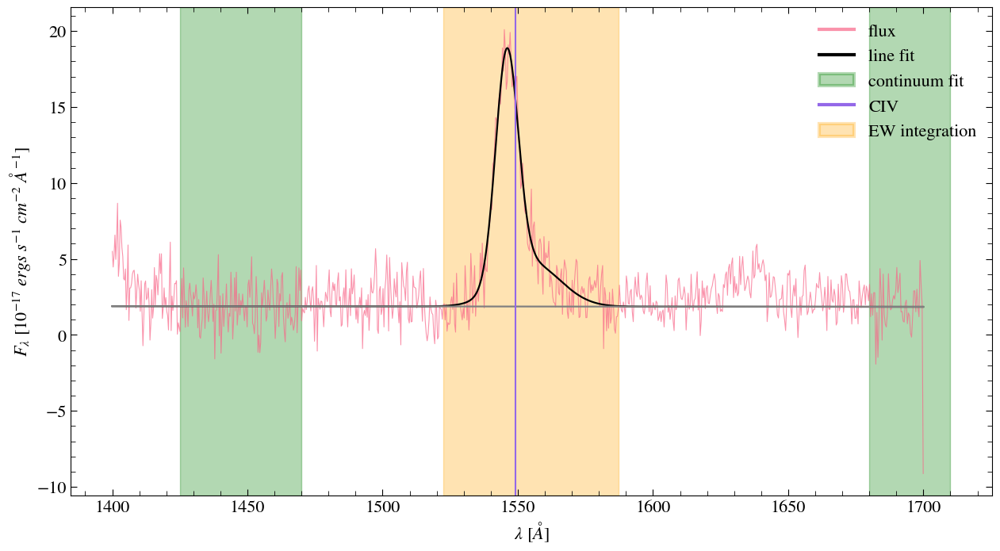


                SDSS: 113349.71+634740.0
                FWHM: 2077.515 vs 2081.074 (Hamann)
                REW: 126.722 vs 120.702 (Hamann)
                kt80: 0.323 vs 0.337 (Hamann)
    


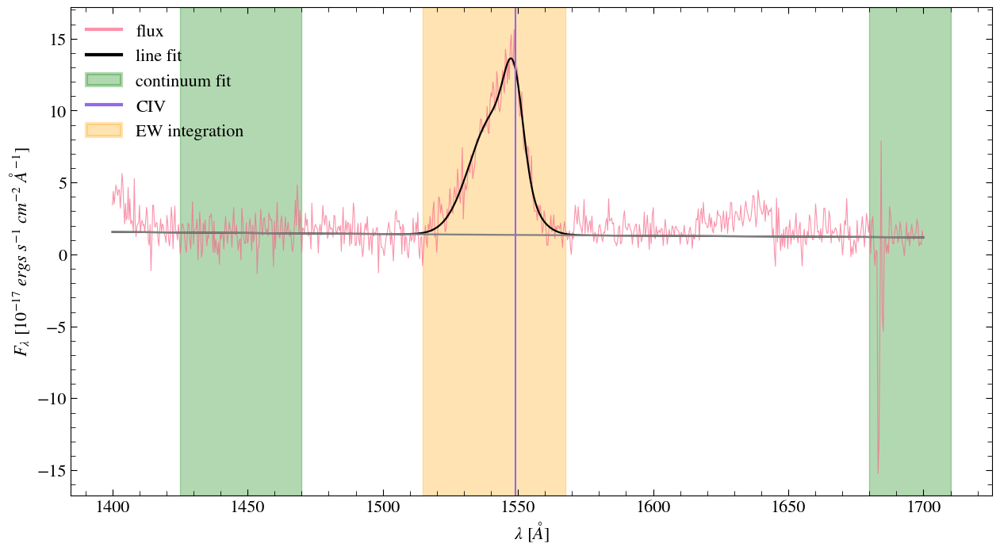


                SDSS: 113834.68+473250.0
                FWHM: 3577.535 vs 3296.45 (Hamann)
                REW: 174.56 vs 176.935 (Hamann)
                kt80: 0.26 vs 0.223 (Hamann)
    


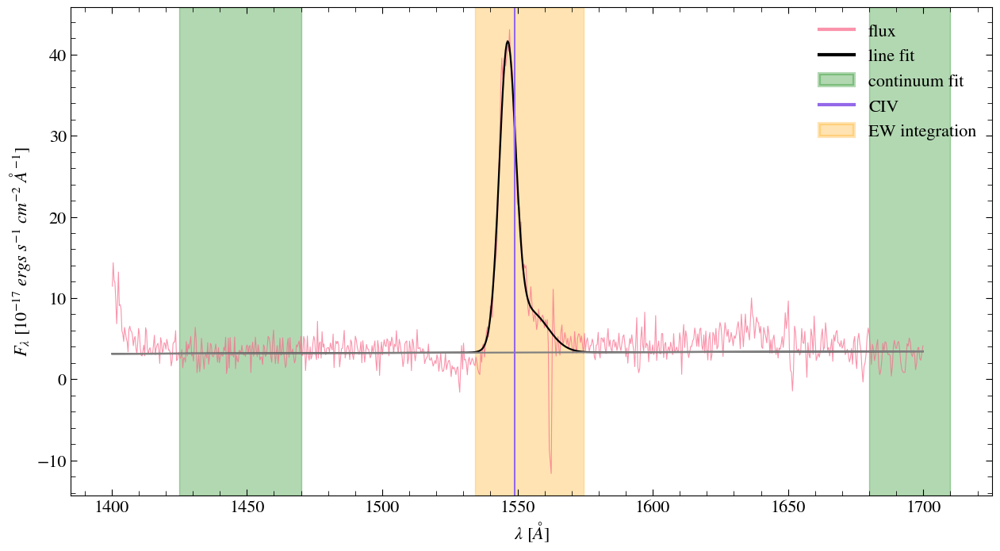


                SDSS: 121253.47+595801.2
                FWHM: 1447.837 vs 1402.242 (Hamann)
                REW: 109.381 vs 106.836 (Hamann)
                kt80: 0.341 vs 0.341 (Hamann)
    


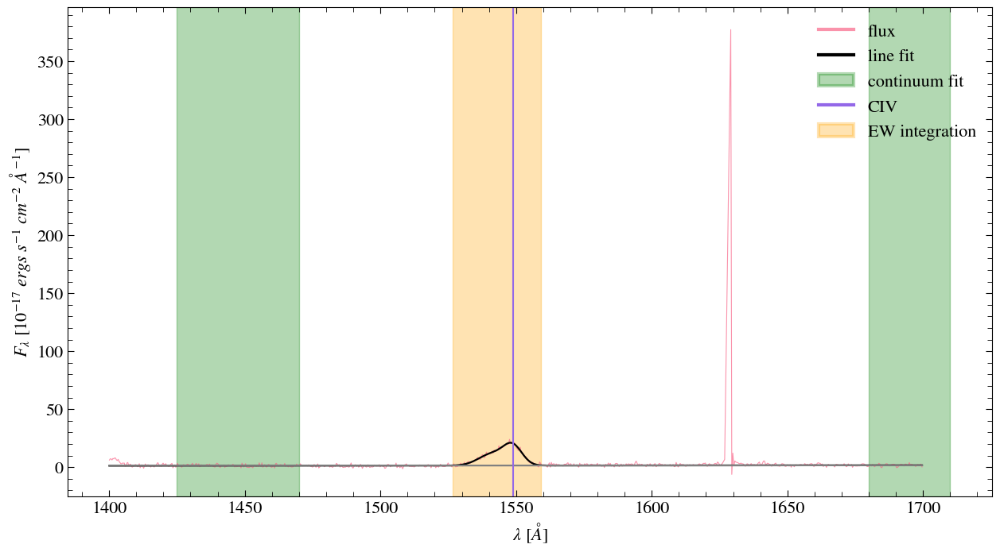


                SDSS: 121704.70+023417.1
                FWHM: 2522.63 vs 2603.968 (Hamann)
                REW: 182.904 vs 180.897 (Hamann)
                kt80: 0.294 vs 0.369 (Hamann)
    


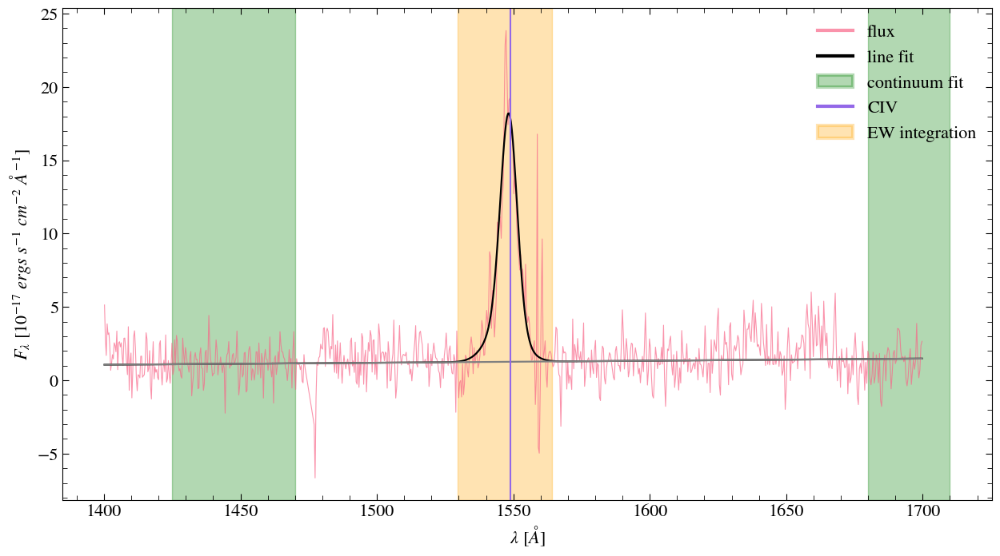


                SDSS: 122000.68+064045.3
                FWHM: 1494.011 vs 1047.131 (Hamann)
                REW: 113.581 vs 112.877 (Hamann)
                kt80: 0.349 vs 0.151 (Hamann)
    


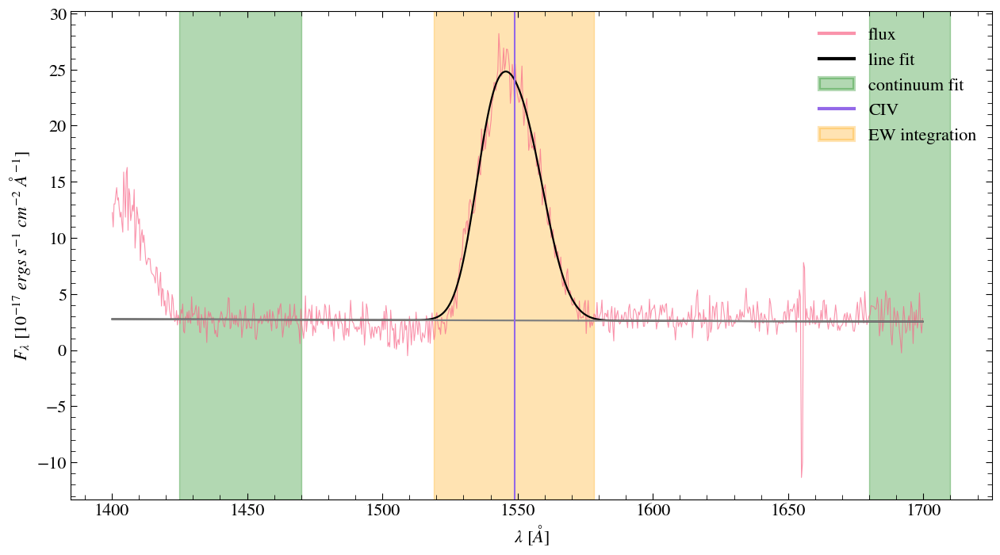


                SDSS: 123241.73+091209.3
                FWHM: 4982.557 vs 4786.658 (Hamann)
                REW: 221.752 vs 224.515 (Hamann)
                kt80: 0.418 vs 0.369 (Hamann)
    


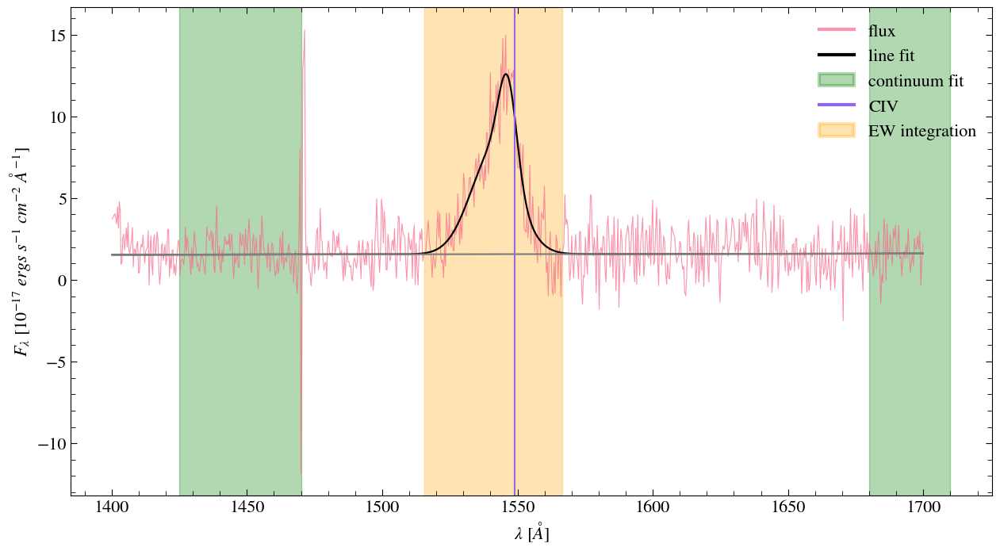


                SDSS: 124106.97+295220.8
                FWHM: 2758.809 vs 2599.948 (Hamann)
                REW: 114.333 vs 137.98 (Hamann)
                kt80: 0.254 vs 0.199 (Hamann)
    


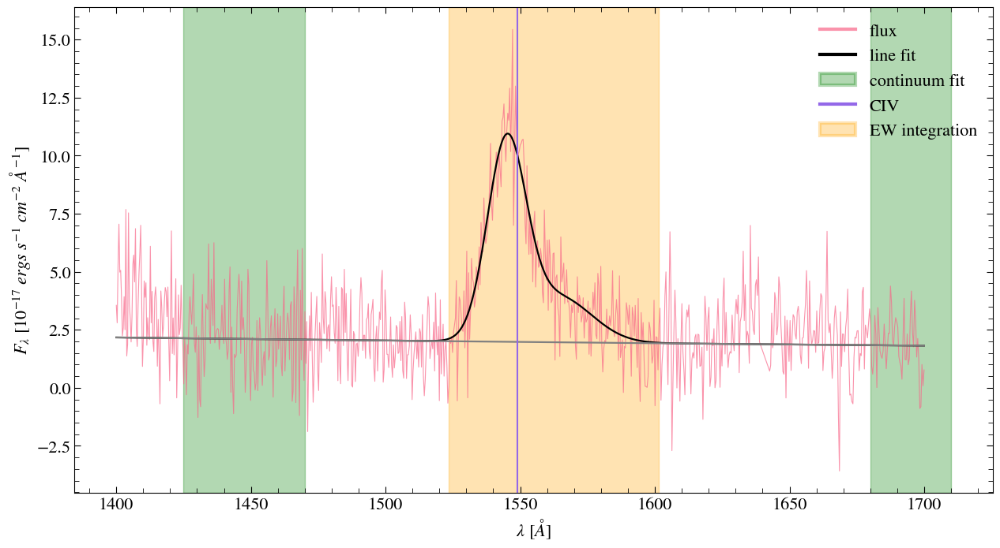


                SDSS: 124738.40+501517.7
                FWHM: 3589.509 vs 3268.048 (Hamann)
                REW: 107.347 vs 134.848 (Hamann)
                kt80: 0.273 vs 0.293 (Hamann)
    


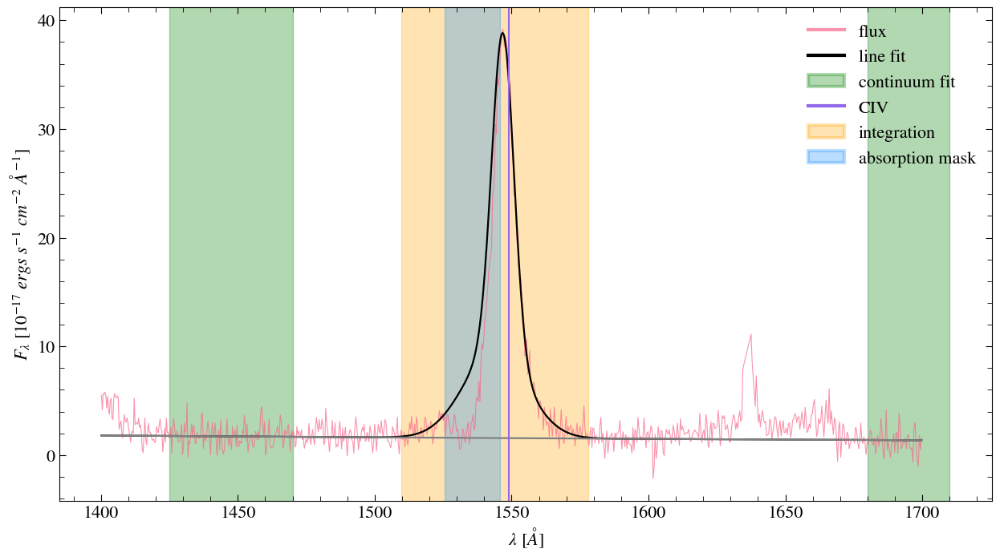


                SDSS: 125019.46+630638.6
                FWHM: 2123.949 vs 1881.225 (Hamann)
                REW: 284.162 vs 242.256 (Hamann)
                kt80: 0.314 vs 0.341 (Hamann)
    


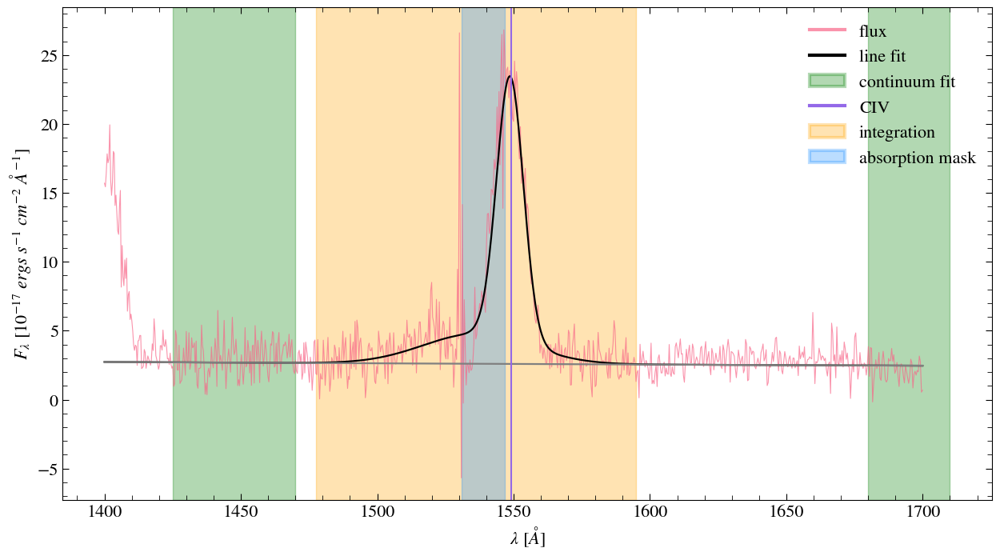


                SDSS: 125449.50+210448.4
                FWHM: 2376.688 vs 2482.204 (Hamann)
                REW: 137.171 vs 140.744 (Hamann)
                kt80: 0.347 vs 0.356 (Hamann)
    


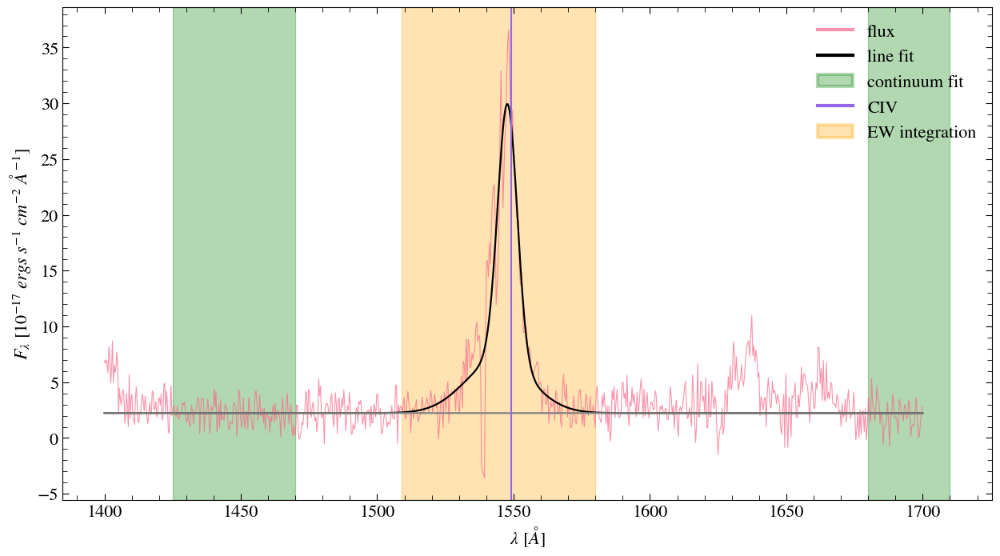


                SDSS: 125811.25+212359.6
                FWHM: 1826.681 vs 1598.848 (Hamann)
                REW: 161.746 vs 158.312 (Hamann)
                kt80: 0.322 vs 0.183 (Hamann)
    


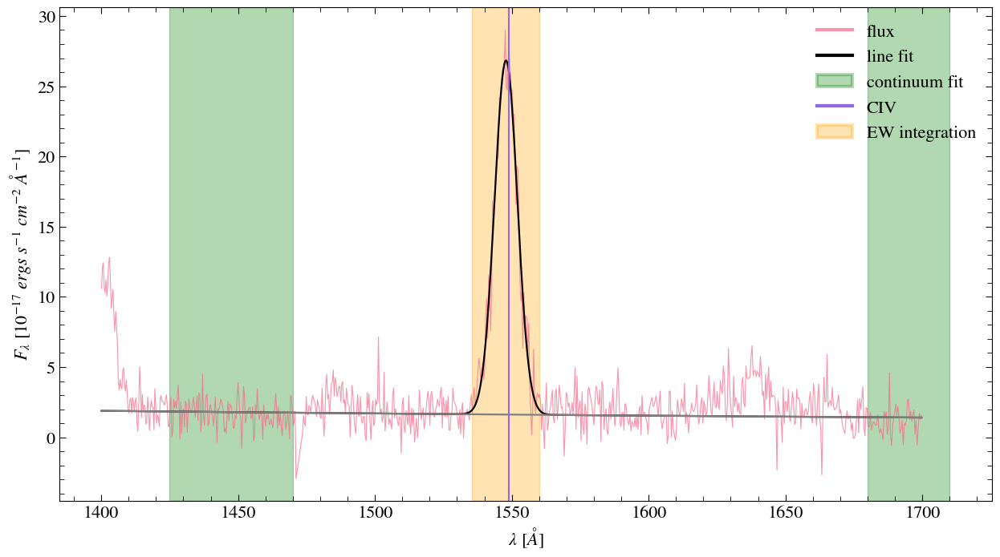


                SDSS: 130114.46+131207.4
                FWHM: 1898.204 vs 1876.523 (Hamann)
                REW: 165.21 vs 185.61 (Hamann)
                kt80: 0.372 vs 0.36 (Hamann)
    


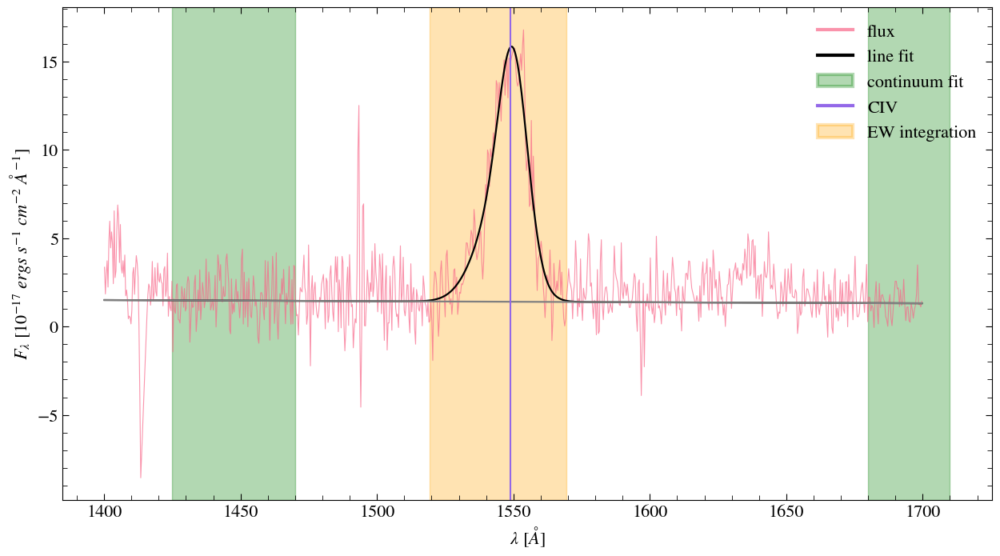


                SDSS: 130421.12+083752.2
                FWHM: 2831.012 vs 3013.626 (Hamann)
                REW: 171.684 vs 131.622 (Hamann)
                kt80: 0.33 vs 0.367 (Hamann)
    


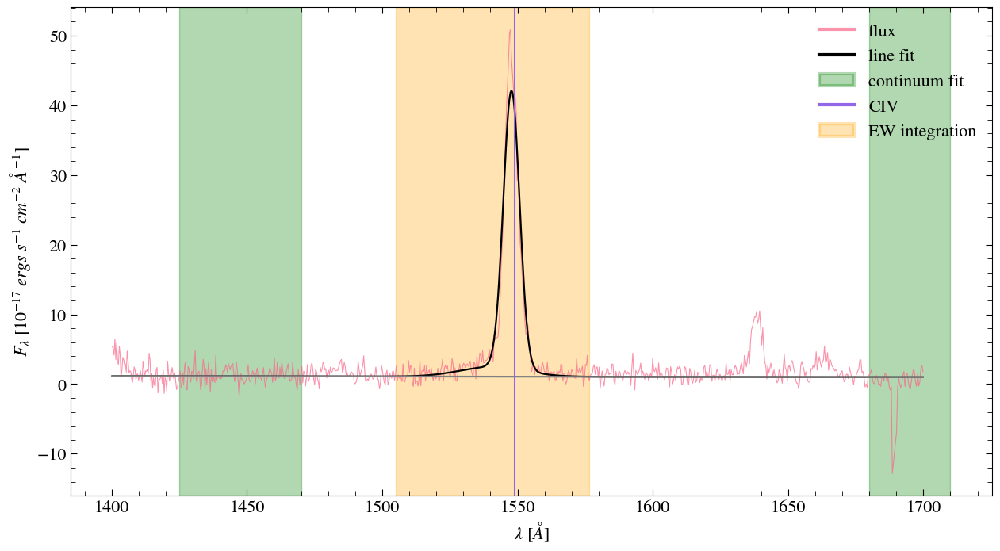


                SDSS: 130630.66+584734.7
                FWHM: 1394.532 vs 1132.847 (Hamann)
                REW: 335.981 vs 331.454 (Hamann)
                kt80: 0.364 vs 0.356 (Hamann)
    


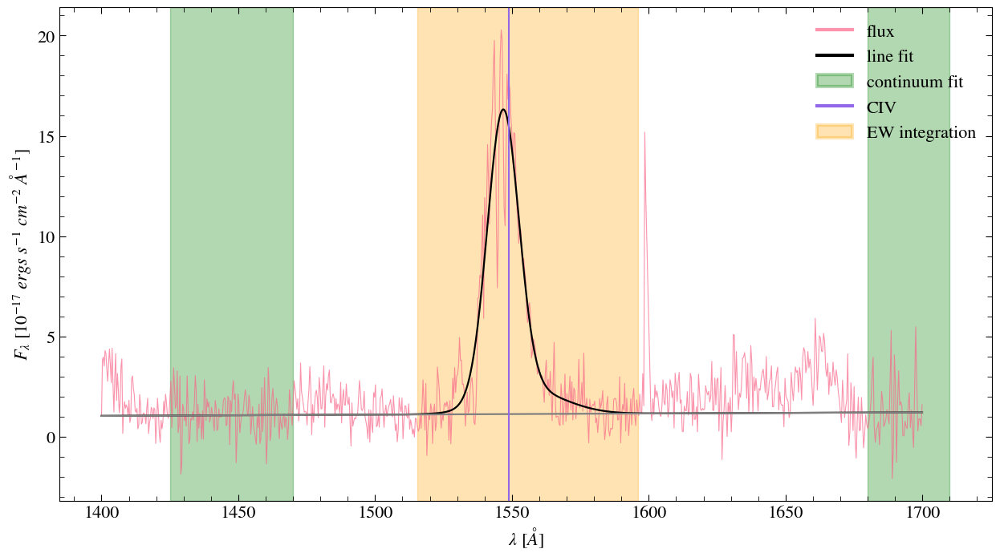


                SDSS: 130654.76+132704.8
                FWHM: 2736.446 vs 2511.169 (Hamann)
                REW: 225.19 vs 196.5 (Hamann)
                kt80: 0.358 vs 0.349 (Hamann)
    


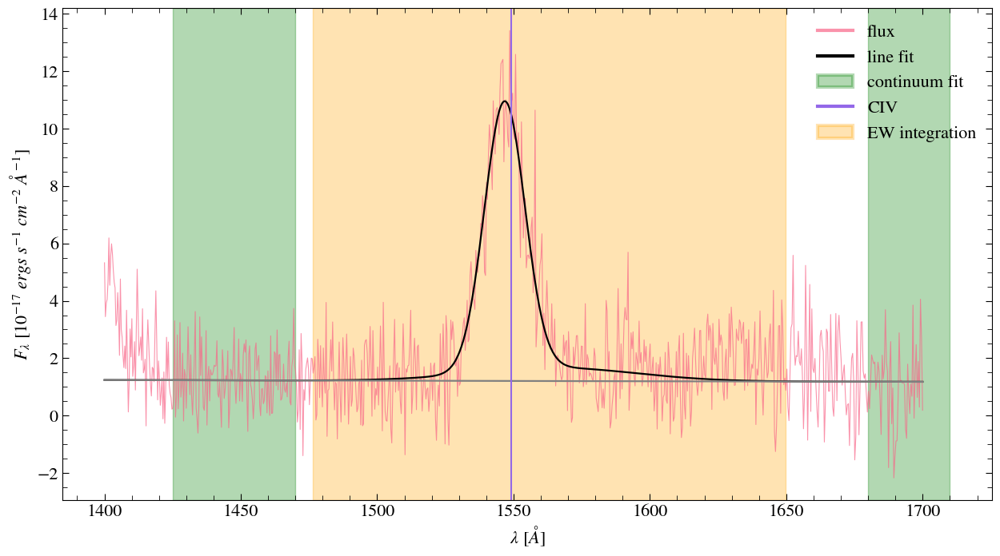


                SDSS: 130936.14+560111.3
                FWHM: 3472.583 vs 3629.606 (Hamann)
                REW: 198.503 vs 160.873 (Hamann)
                kt80: 0.362 vs 0.361 (Hamann)
    


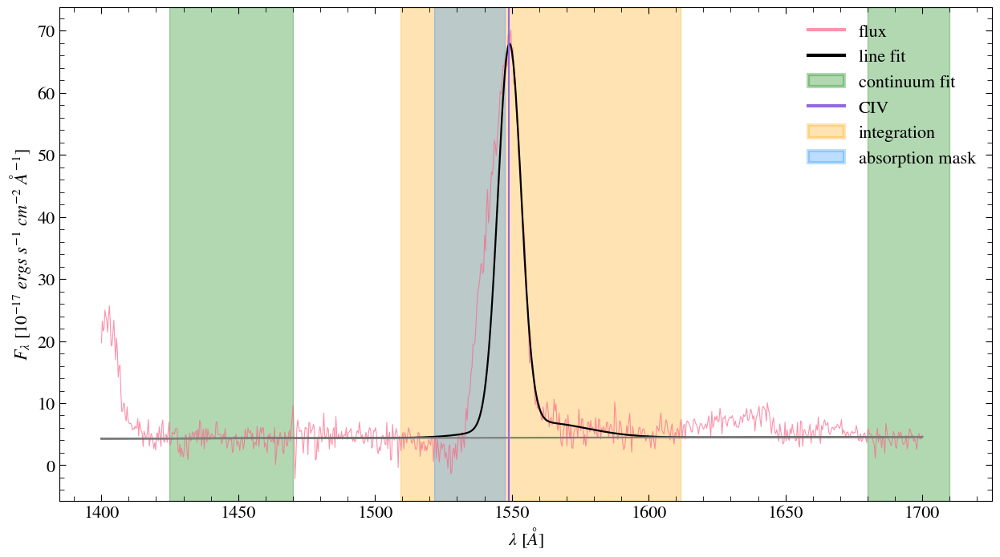


                SDSS: 131047.78+322518.3
                FWHM: 1988.721 vs 2793.839 (Hamann)
                REW: 216.538 vs 226.394 (Hamann)
                kt80: 0.365 vs 0.367 (Hamann)
    


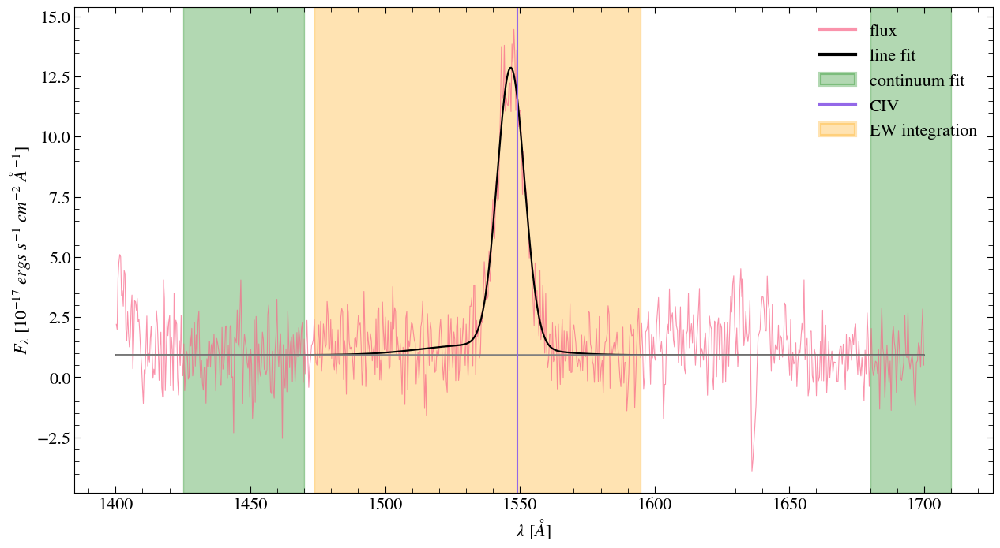


                SDSS: 131722.85+322207.5
                FWHM: 2351.619 vs 2310.771 (Hamann)
                REW: 201.268 vs 159.85 (Hamann)
                kt80: 0.365 vs 0.36 (Hamann)
    


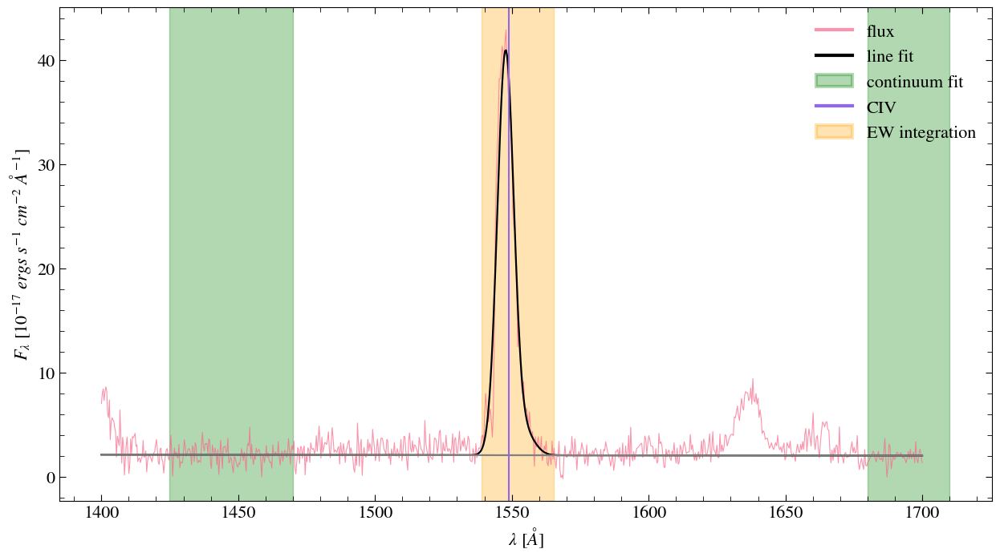


                SDSS: 131833.76+261746.9
                FWHM: 1395.025 vs 1280.057 (Hamann)
                REW: 150.541 vs 149.805 (Hamann)
                kt80: 0.363 vs 0.356 (Hamann)
    


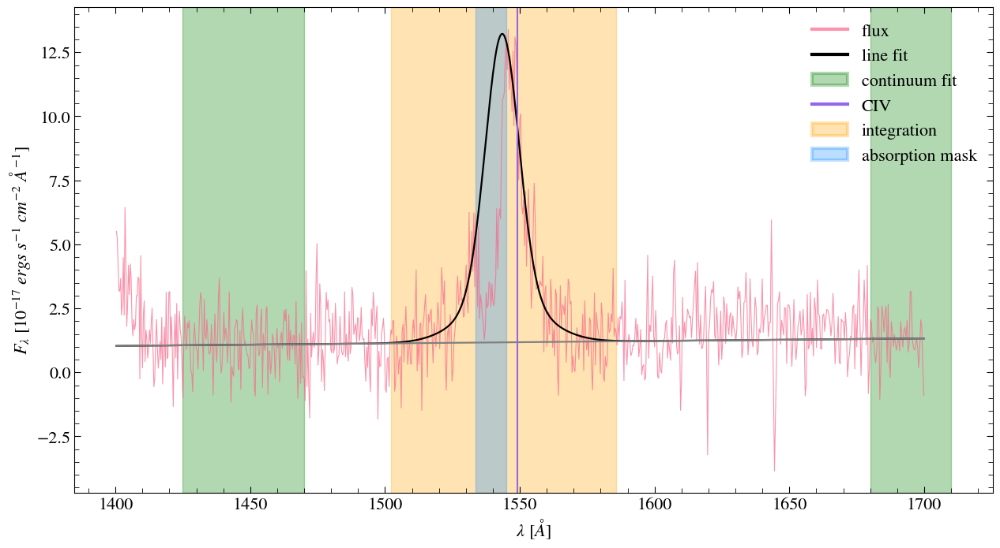


                SDSS: 134001.90+322155.9
                FWHM: 3049.033 vs 1822.703 (Hamann)
                REW: 138.438 vs 130.709 (Hamann)
                kt80: 0.348 vs 0.207 (Hamann)
    


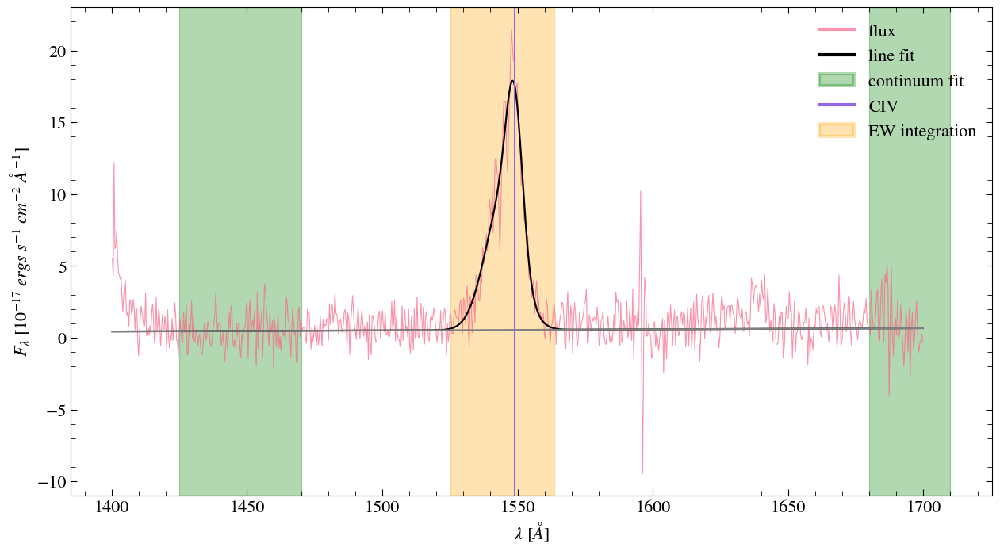


                SDSS: 134026.99+083427.2
                FWHM: 2093.216 vs 2075.846 (Hamann)
                REW: 411.852 vs 357.973 (Hamann)
                kt80: 0.275 vs 0.345 (Hamann)
    


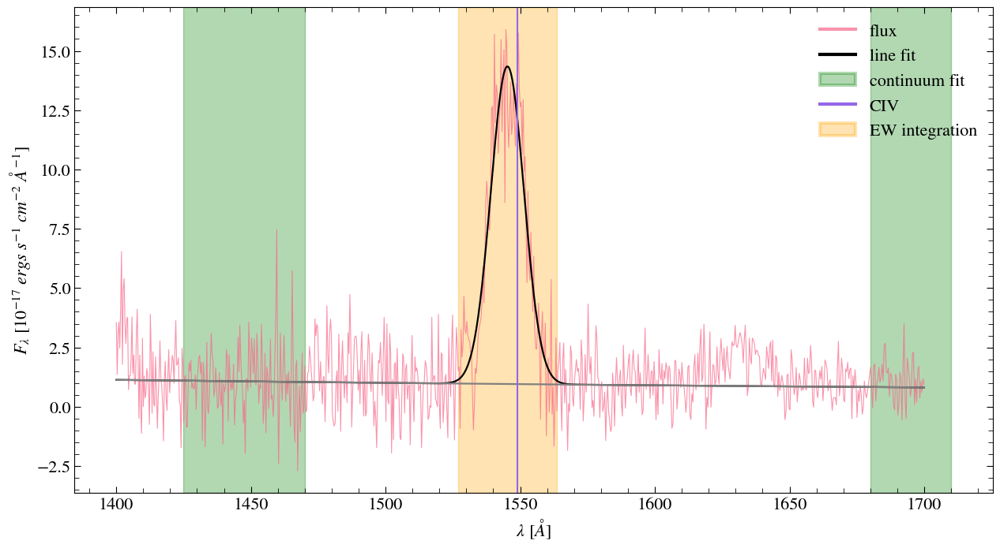


                SDSS: 134417.34+445459.4
                FWHM: 2806.226 vs 2870.515 (Hamann)
                REW: 218.18 vs 309.962 (Hamann)
                kt80: 0.372 vs 0.36 (Hamann)
    


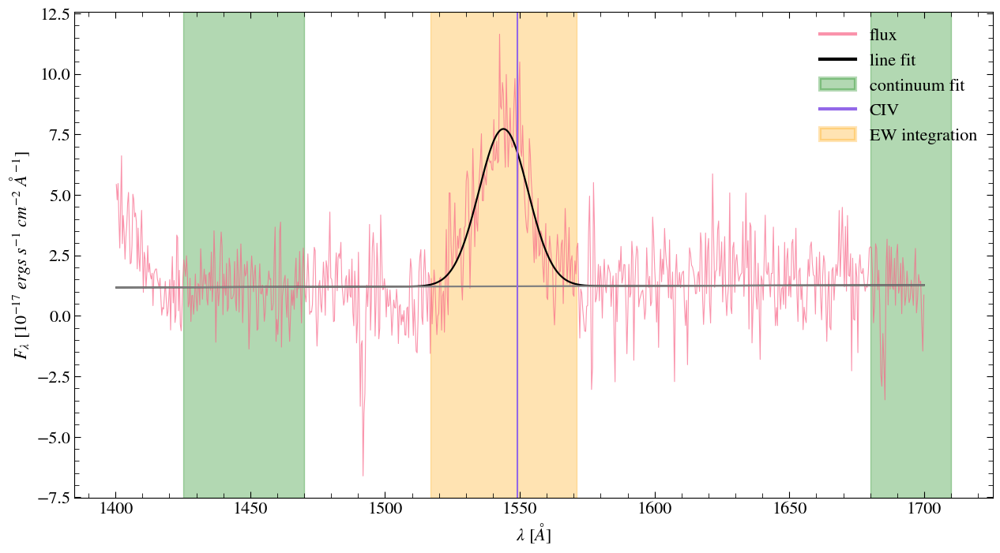


                SDSS: 134450.51+140139.2
                FWHM: 4148.043 vs 4487.034 (Hamann)
                REW: 124.977 vs 132.41 (Hamann)
                kt80: 0.372 vs 0.372 (Hamann)
    


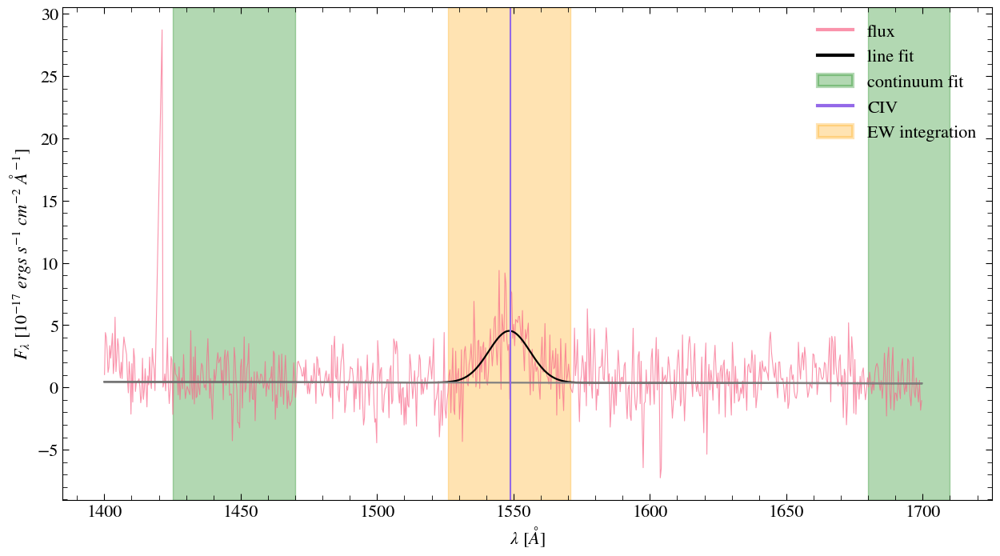


                SDSS: 134535.66+600028.4
                FWHM: 3441.776 vs 6459.524 (Hamann)
                REW: 221.061 vs 141.888 (Hamann)
                kt80: 0.372 vs 0.372 (Hamann)
    


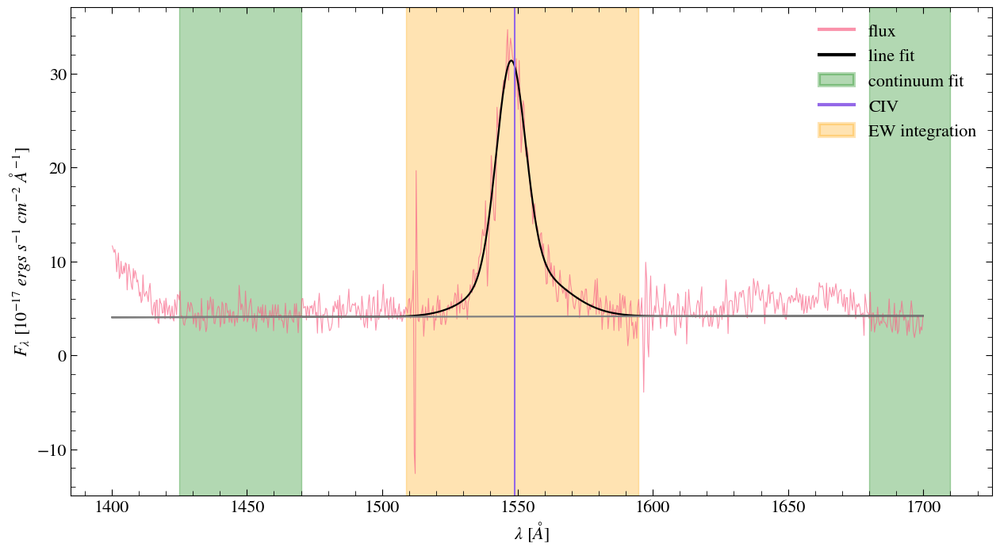


                SDSS: 135557.60+144733.1
                FWHM: 2747.528 vs 2958.323 (Hamann)
                REW: 118.608 vs 117.885 (Hamann)
                kt80: 0.324 vs 0.336 (Hamann)
    


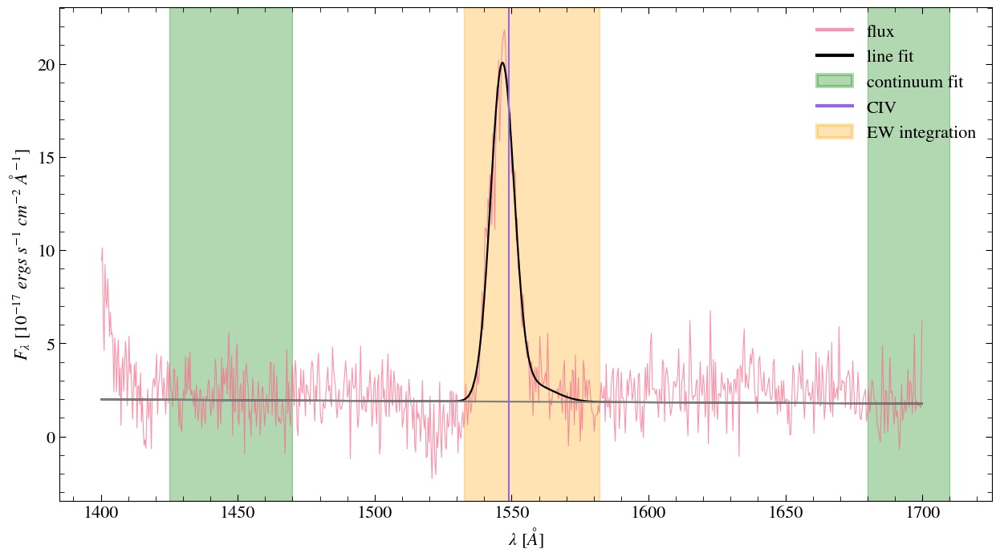


                SDSS: 135608.32+073017.2
                FWHM: 1994.932 vs 2043.349 (Hamann)
                REW: 111.899 vs 109.67 (Hamann)
                kt80: 0.364 vs 0.372 (Hamann)
    


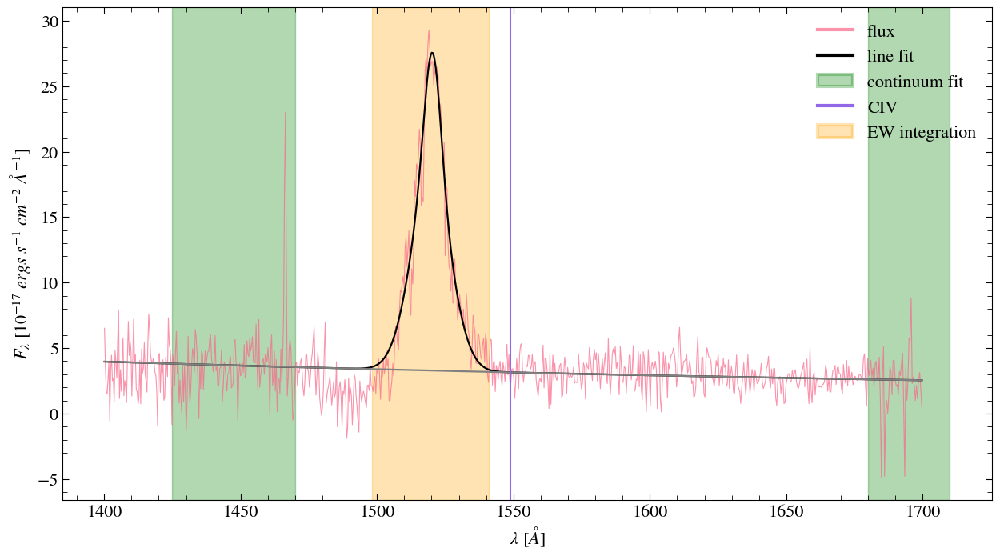


                SDSS: 140506.80+543227.3
                FWHM: 2218.836 vs 2639.806 (Hamann)
                REW: 100.375 vs 122.571 (Hamann)
                kt80: 0.276 vs 0.357 (Hamann)
    


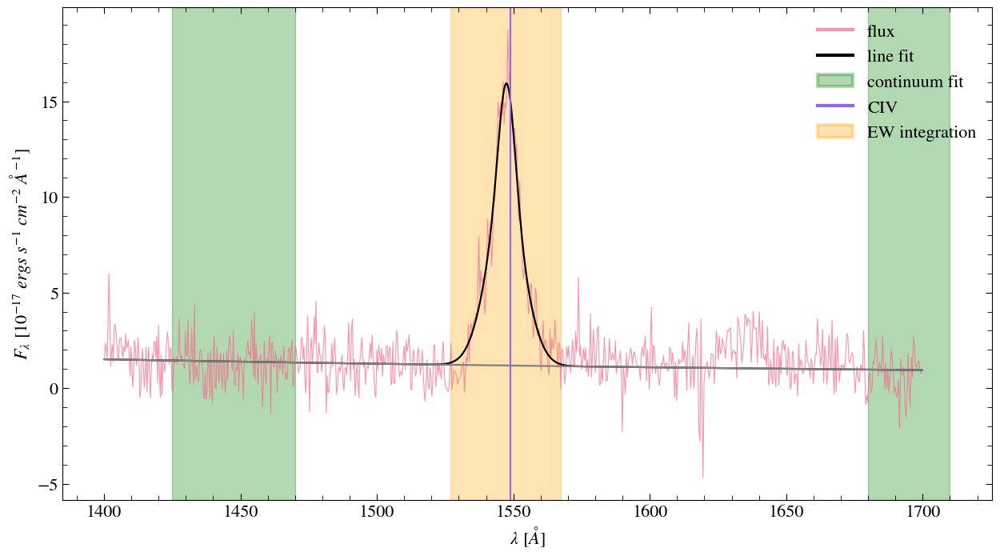


                SDSS: 141350.76+214307.7
                FWHM: 2078.355 vs 2356.276 (Hamann)
                REW: 161.113 vs 207.617 (Hamann)
                kt80: 0.284 vs 0.358 (Hamann)
    


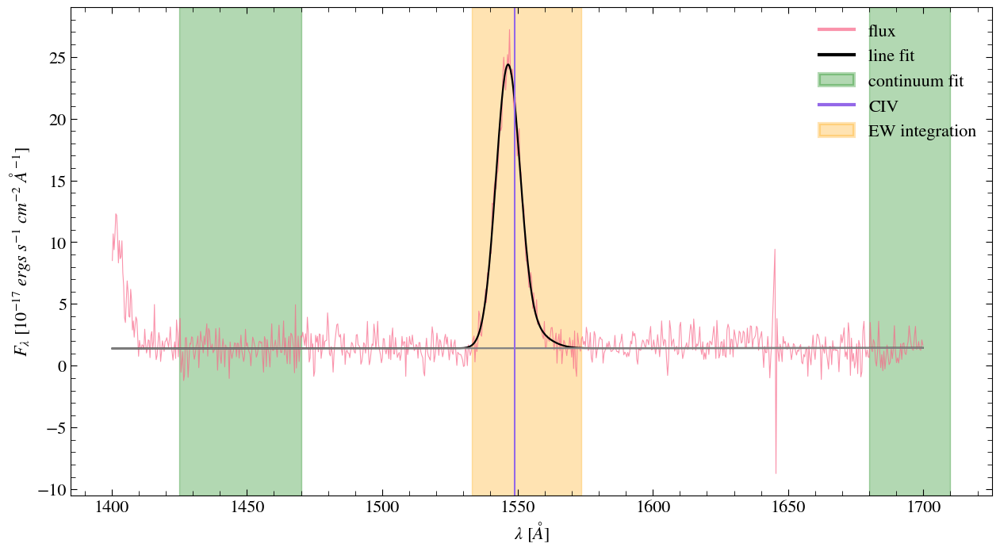


                SDSS: 143159.76+173032.6
                FWHM: 2066.388 vs 2084.241 (Hamann)
                REW: 190.373 vs 176.894 (Hamann)
                kt80: 0.364 vs 0.368 (Hamann)
    


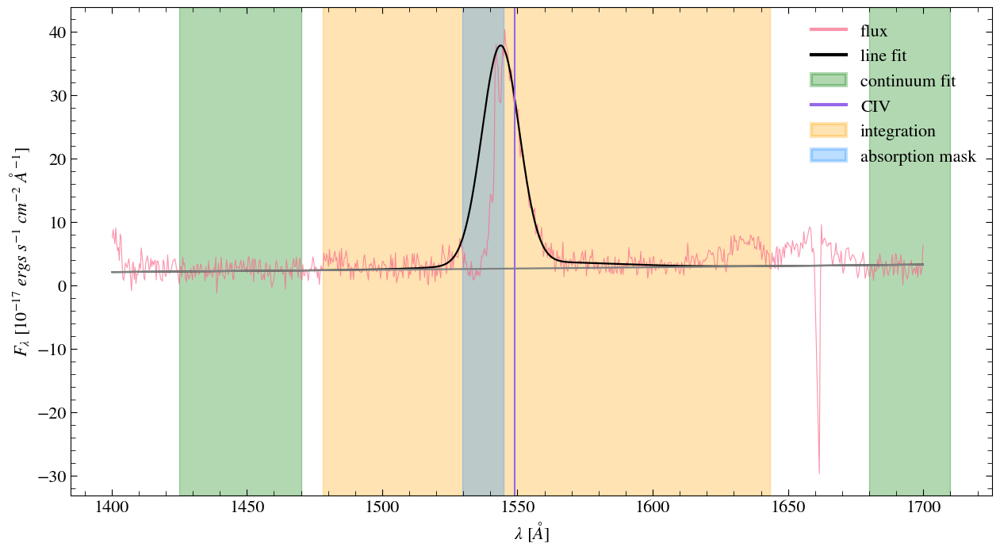


                SDSS: 145354.70+190343.9
                FWHM: 3193.185 vs 2046.257 (Hamann)
                REW: 206.235 vs 141.71 (Hamann)
                kt80: 0.367 vs 0.35 (Hamann)
    


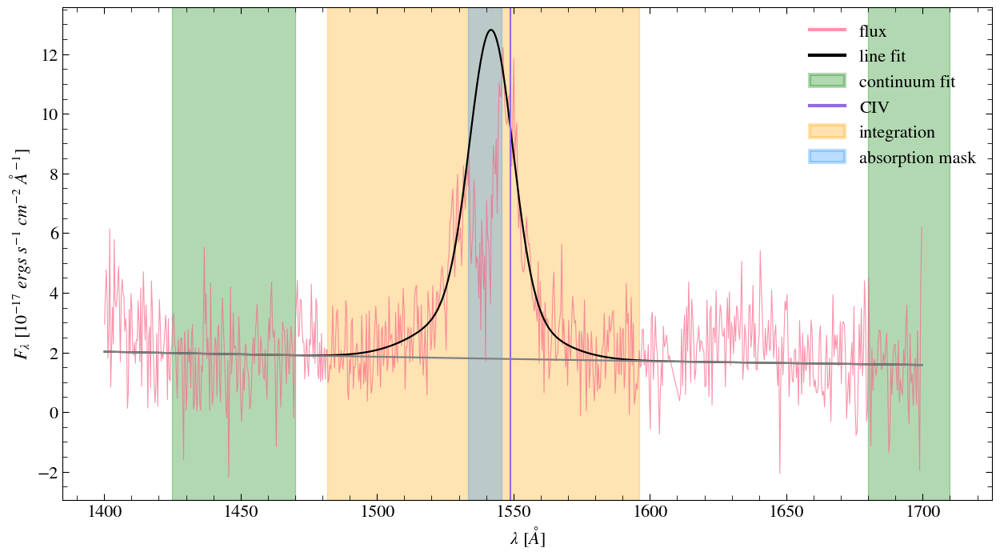


                SDSS: 145623.35+214516.2
                FWHM: 3932.466 vs 4421.831 (Hamann)
                REW: 117.005 vs 102.644 (Hamann)
                kt80: 0.34 vs 0.364 (Hamann)
    


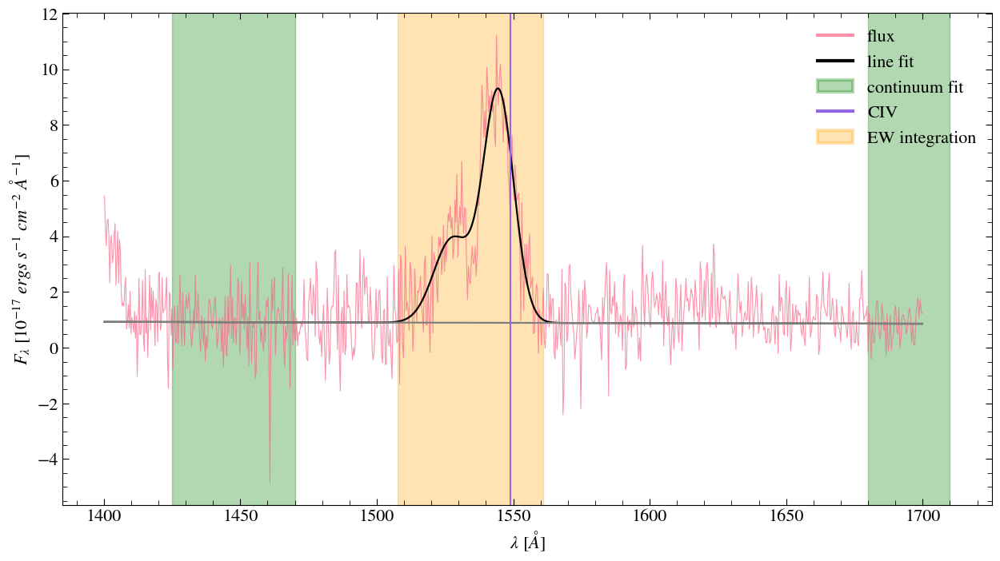


                SDSS: 150117.07+231730.9
                FWHM: 2812.344 vs 4034.664 (Hamann)
                REW: 190.904 vs 231.046 (Hamann)
                kt80: 0.23 vs 0.235 (Hamann)
    


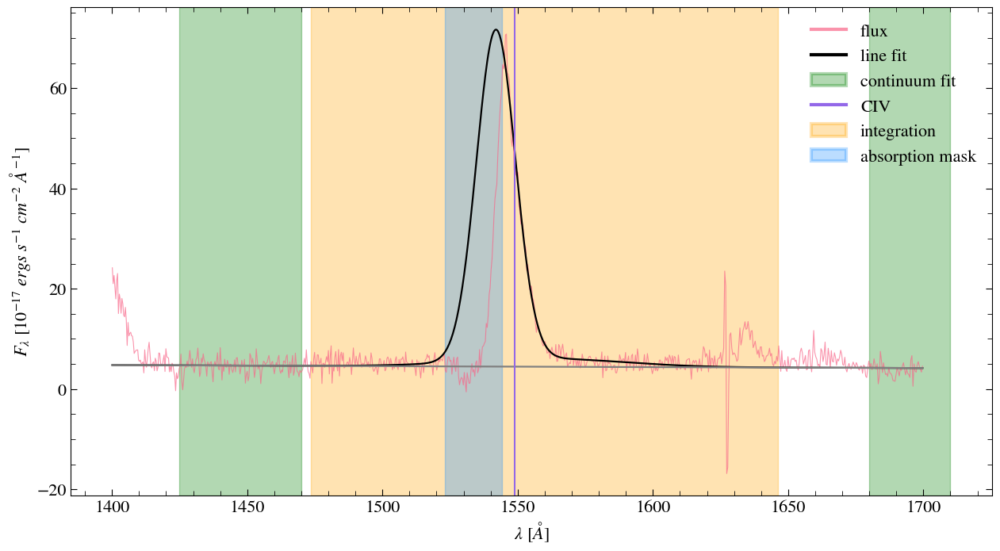


                SDSS: 152941.01+464517.6
                FWHM: 3328.271 vs 1896.472 (Hamann)
                REW: 187.856 vs 158.864 (Hamann)
                kt80: 0.367 vs 0.348 (Hamann)
    


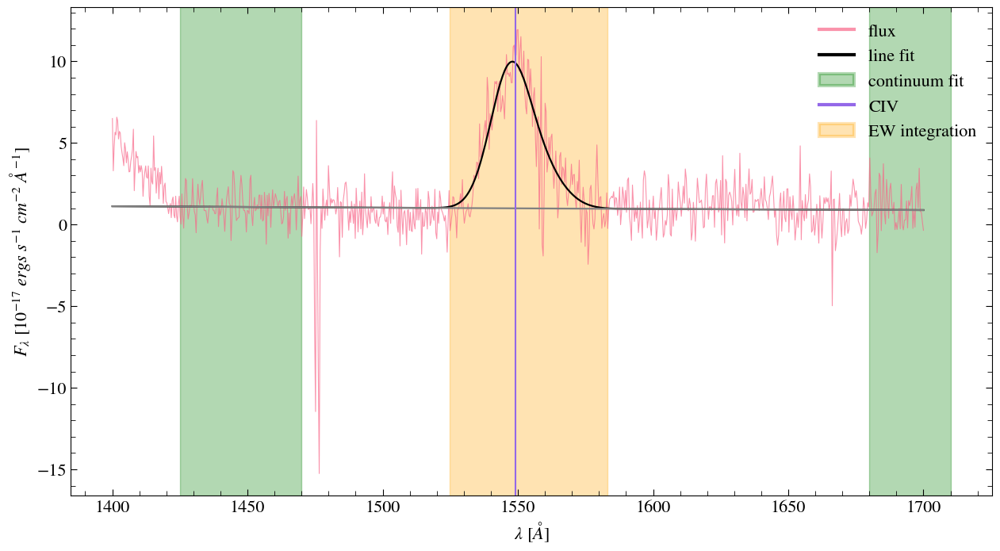


                SDSS: 153107.14+105825.8
                FWHM: 3832.366 vs 3936.554 (Hamann)
                REW: 189.703 vs 151.904 (Hamann)
                kt80: 0.347 vs 0.372 (Hamann)
    


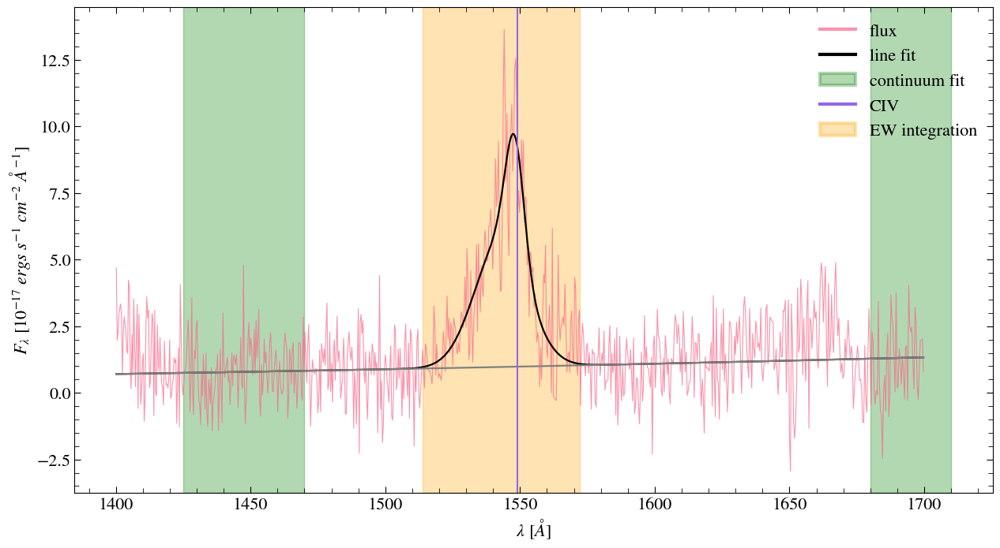


                SDSS: 153108.10+213725.1
                FWHM: 2825.957 vs 2766.583 (Hamann)
                REW: 171.937 vs 212.521 (Hamann)
                kt80: 0.235 vs 0.26 (Hamann)
    


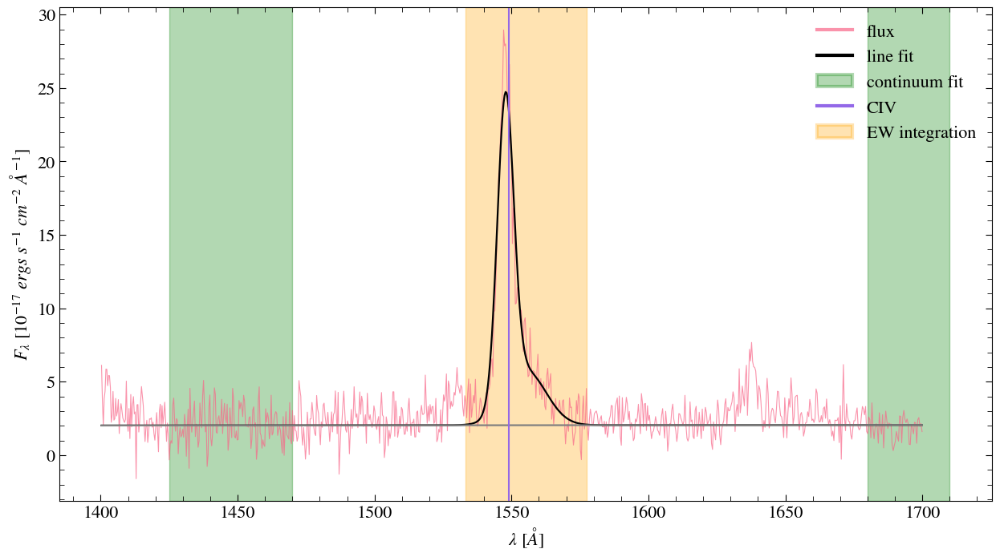


                SDSS: 153446.26+515933.8
                FWHM: 1483.298 vs 1156.431 (Hamann)
                REW: 112.765 vs 126.687 (Hamann)
                kt80: 0.325 vs 0.283 (Hamann)
    


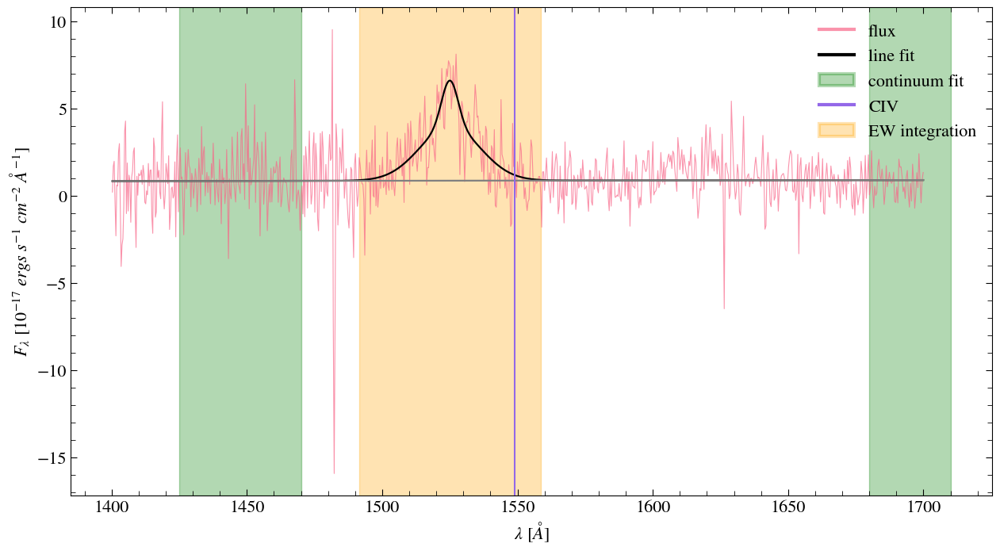


                SDSS: 154243.87+102001.5
                FWHM: 2506.517 vs 3901.128 (Hamann)
                REW: 119.273 vs 114.106 (Hamann)
                kt80: 0.19 vs 0.372 (Hamann)
    


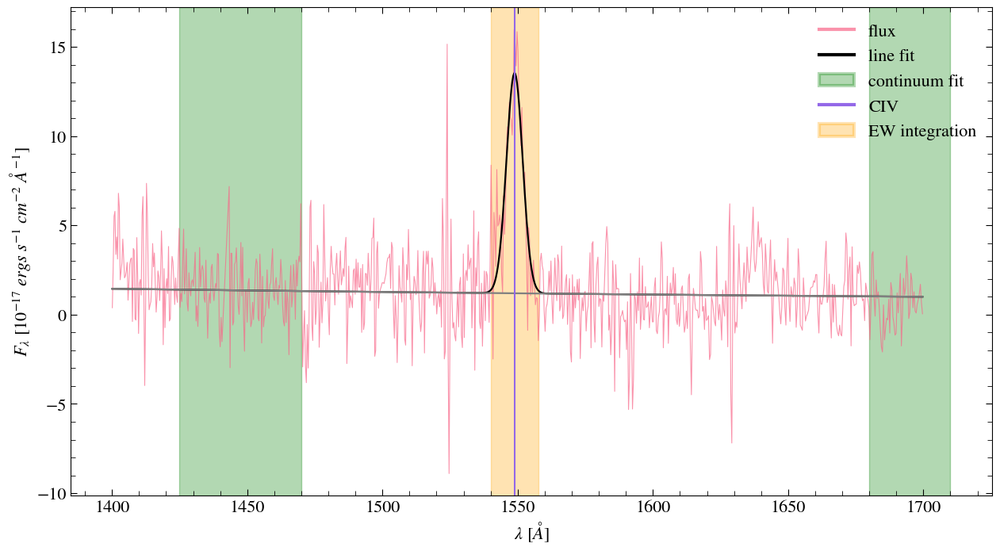


                SDSS: 154743.78+615431.1
                FWHM: 1368.779 vs 1176.837 (Hamann)
                REW: 79.464 vs 128.087 (Hamann)
                kt80: 0.373 vs 0.262 (Hamann)
    


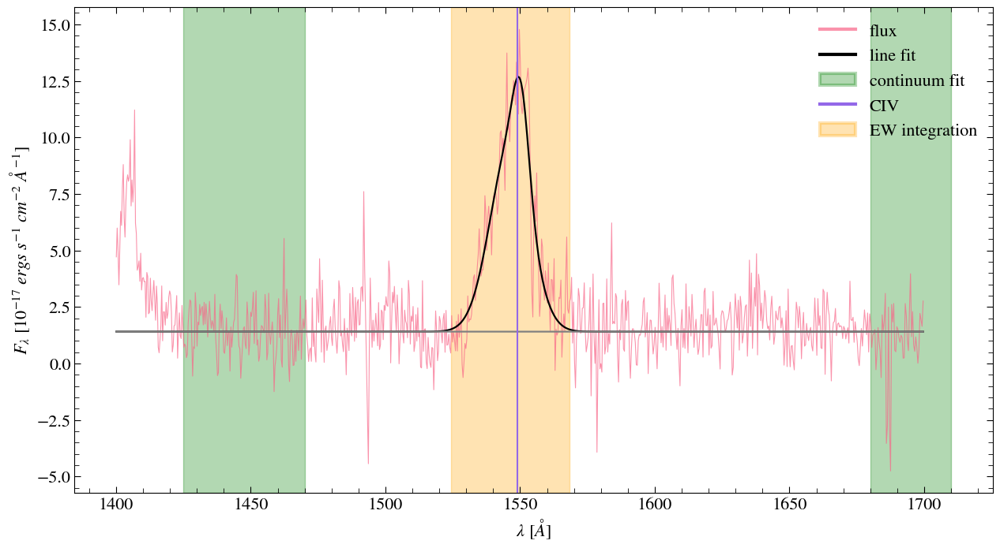


                SDSS: 154831.92+311951.4
                FWHM: 2873.448 vs 3050.048 (Hamann)
                REW: 131.288 vs 127.184 (Hamann)
                kt80: 0.296 vs 0.372 (Hamann)
    


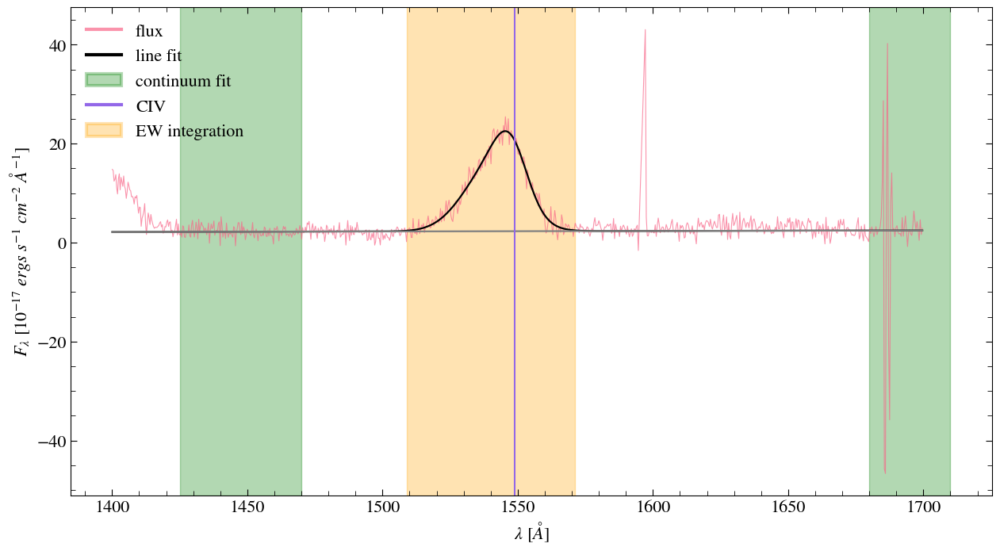


                SDSS: 160431.55+563354.2
                FWHM: 4188.495 vs 4221.468 (Hamann)
                REW: 207.454 vs 204.844 (Hamann)
                kt80: 0.332 vs 0.343 (Hamann)
    


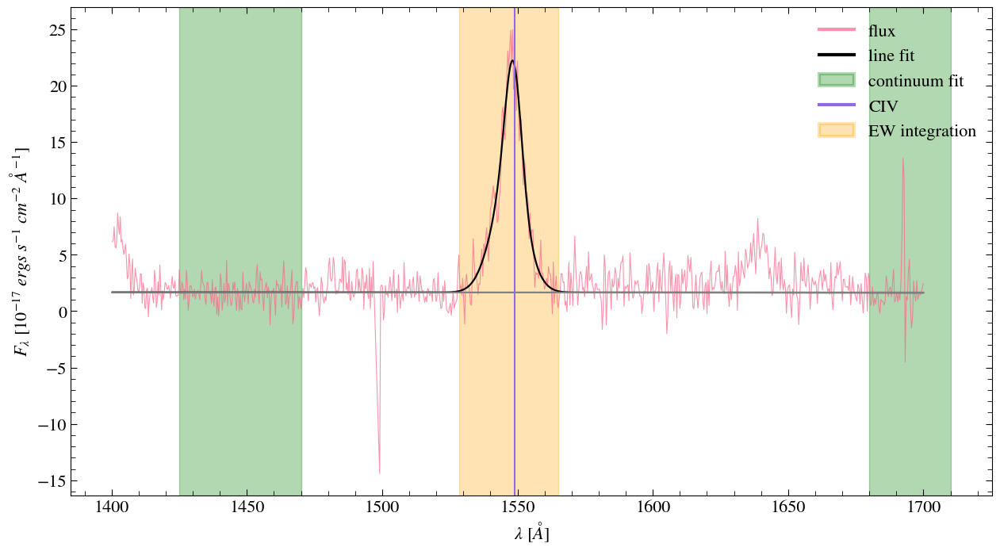


                SDSS: 164725.72+522948.6
                FWHM: 1840.723 vs 1905.323 (Hamann)
                REW: 140.632 vs 123.928 (Hamann)
                kt80: 0.301 vs 0.348 (Hamann)
    


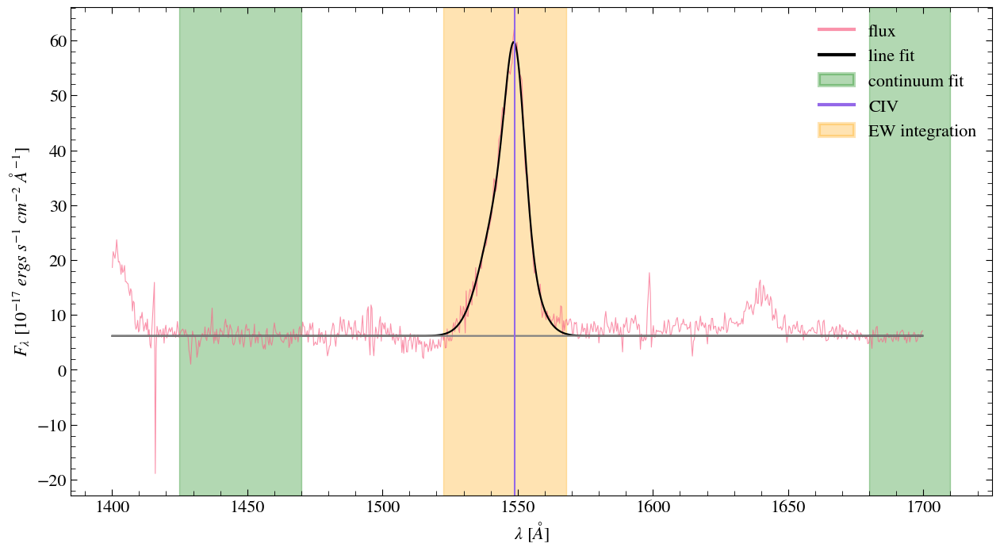


                SDSS: 165202.64+172852.3
                FWHM: 2345.243 vs 2403.322 (Hamann)
                REW: 125.553 vs 124.521 (Hamann)
                kt80: 0.28 vs 0.329 (Hamann)
    
ValueError in get_absorption_interval()


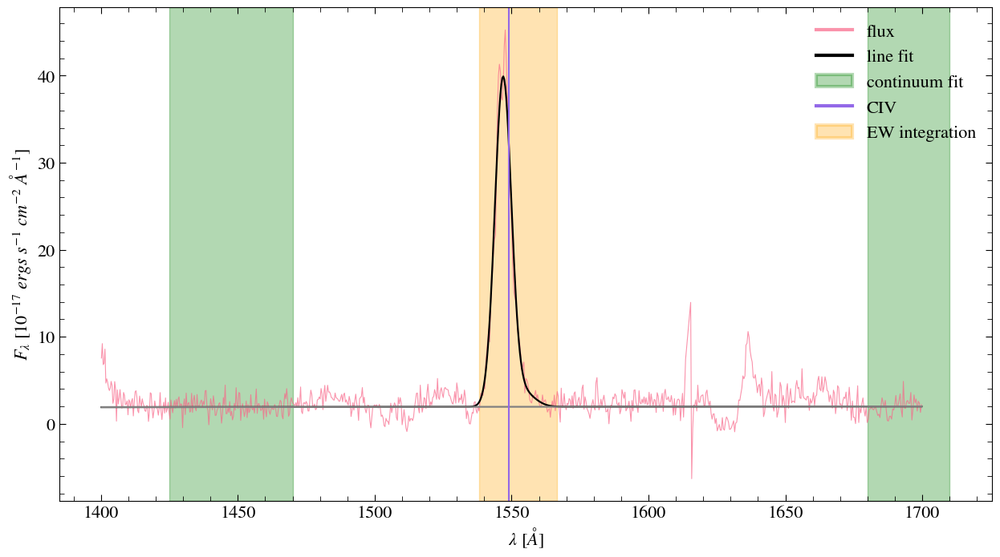


                SDSS: 170558.64+273624.7
                FWHM: 1390.5 vs 1300.839 (Hamann)
                REW: 155.981 vs 157.472 (Hamann)
                kt80: 0.364 vs 0.359 (Hamann)
    


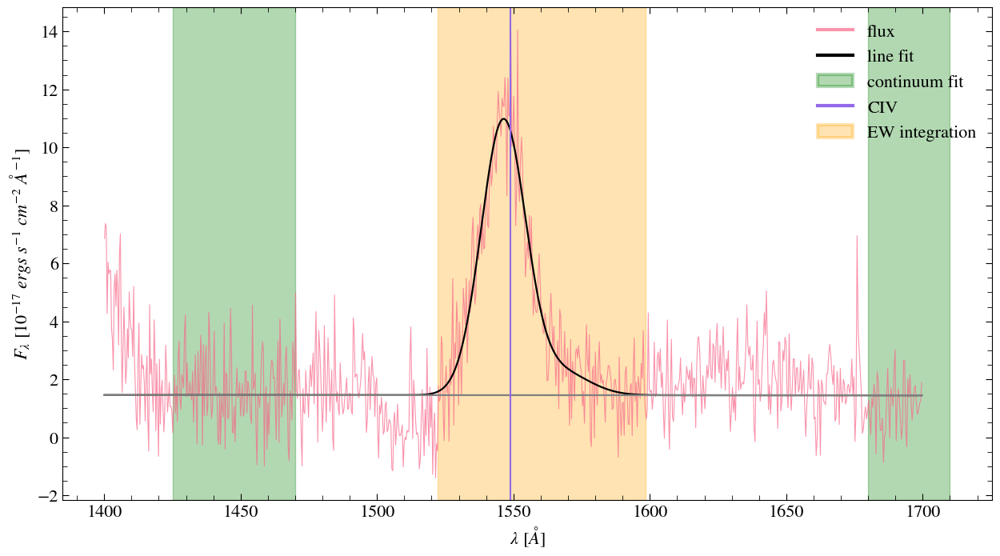


                SDSS: 171420.38+414815.7
                FWHM: 3822.564 vs 3815.54 (Hamann)
                REW: 151.437 vs 129.999 (Hamann)
                kt80: 0.355 vs 0.359 (Hamann)
    


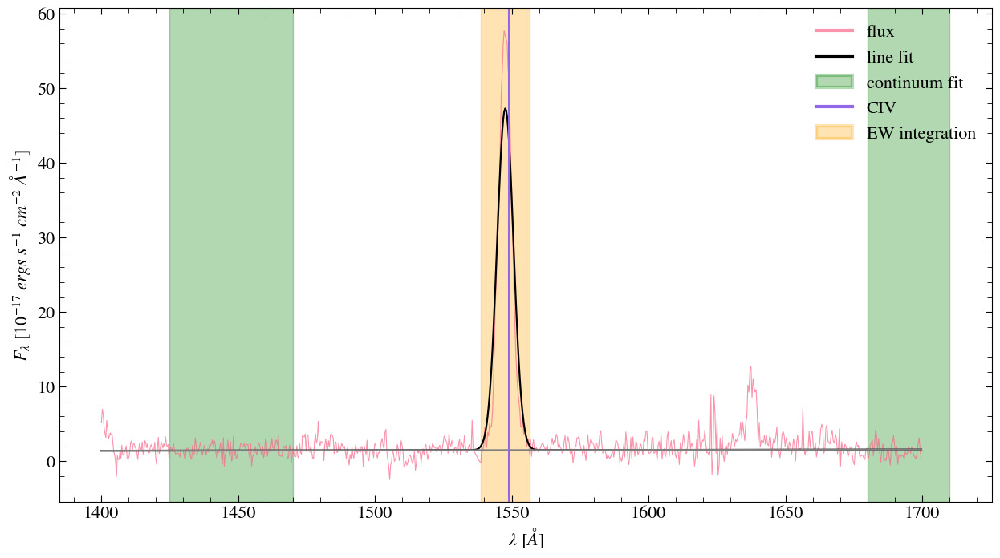


                SDSS: 220337.79+121955.3
                FWHM: 1367.246 vs 1070.213 (Hamann)
                REW: 227.564 vs 266.278 (Hamann)
                kt80: 0.372 vs 0.37 (Hamann)
    


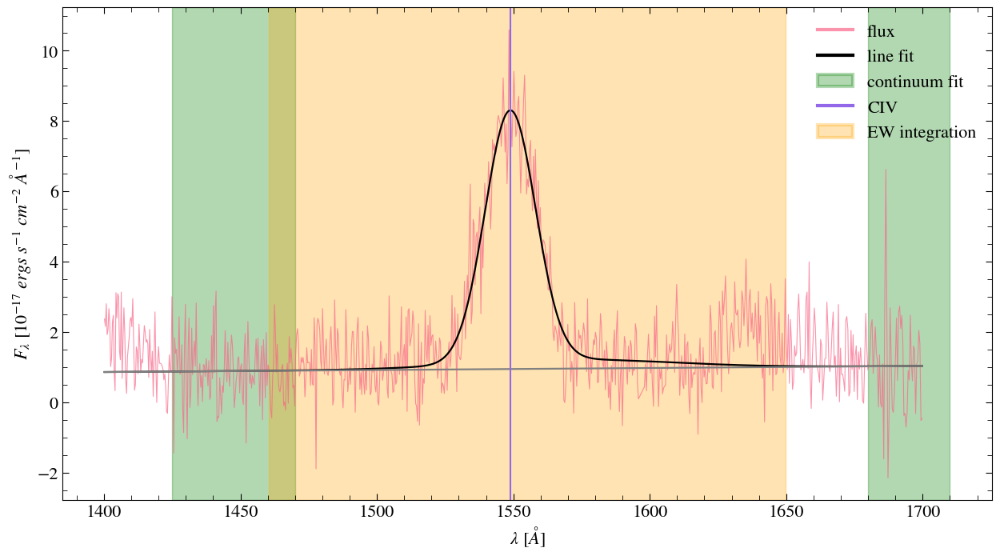


                SDSS: 221524.00-005643.8
                FWHM: 4297.884 vs 4280.102 (Hamann)
                REW: 230.391 vs 153.336 (Hamann)
                kt80: 0.365 vs 0.366 (Hamann)
    


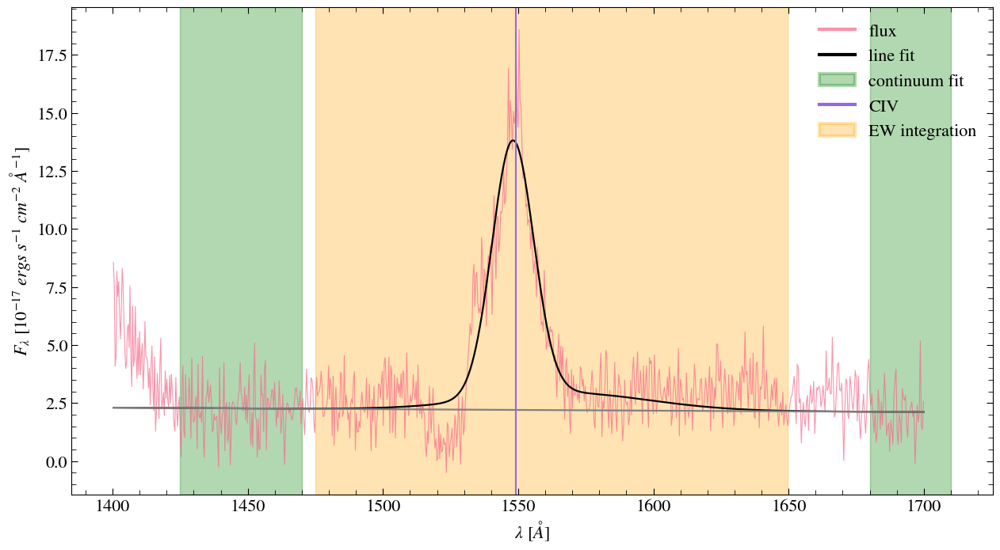


                SDSS: 222421.63+174041.2
                FWHM: 3639.02 vs 2748.994 (Hamann)
                REW: 137.877 vs 110.457 (Hamann)
                kt80: 0.358 vs 0.191 (Hamann)
    


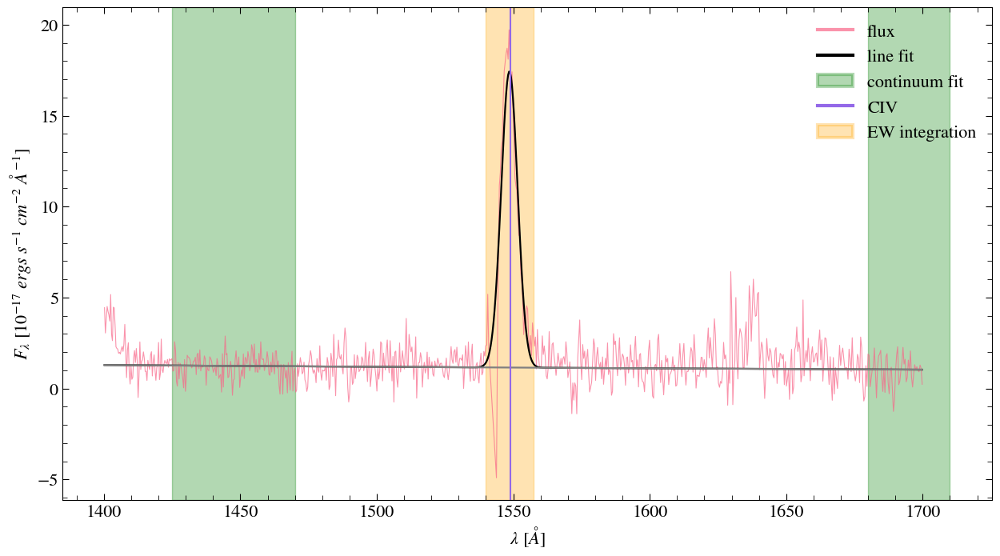


                SDSS: 223754.52+065026.6
                FWHM: 1368.148 vs 1390.575 (Hamann)
                REW: 98.725 vs 140.677 (Hamann)
                kt80: 0.372 vs 0.356 (Hamann)
    


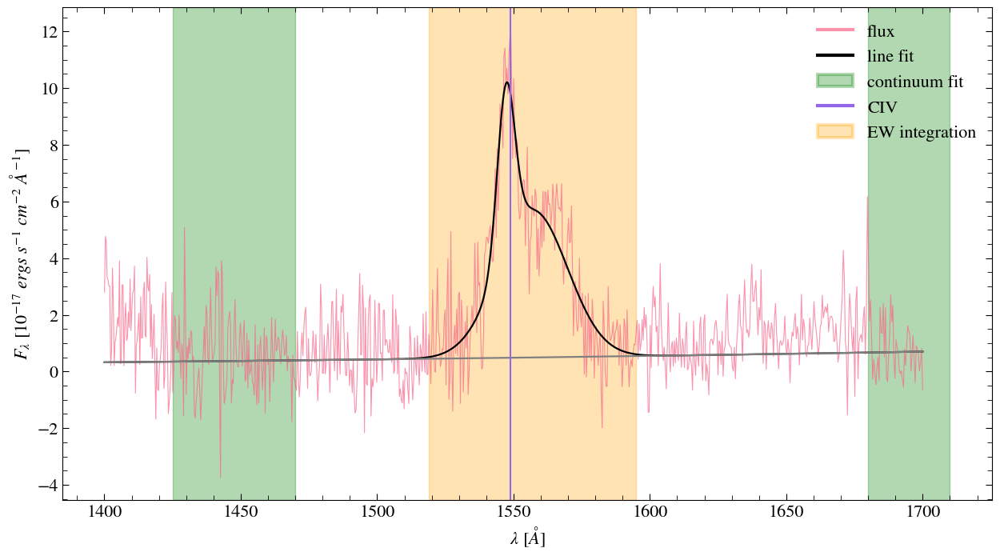


                SDSS: 225438.30+232714.5
                FWHM: 3668.76 vs 4411.578 (Hamann)
                REW: 450.243 vs 415.245 (Hamann)
                kt80: 0.159 vs 0.358 (Hamann)
    


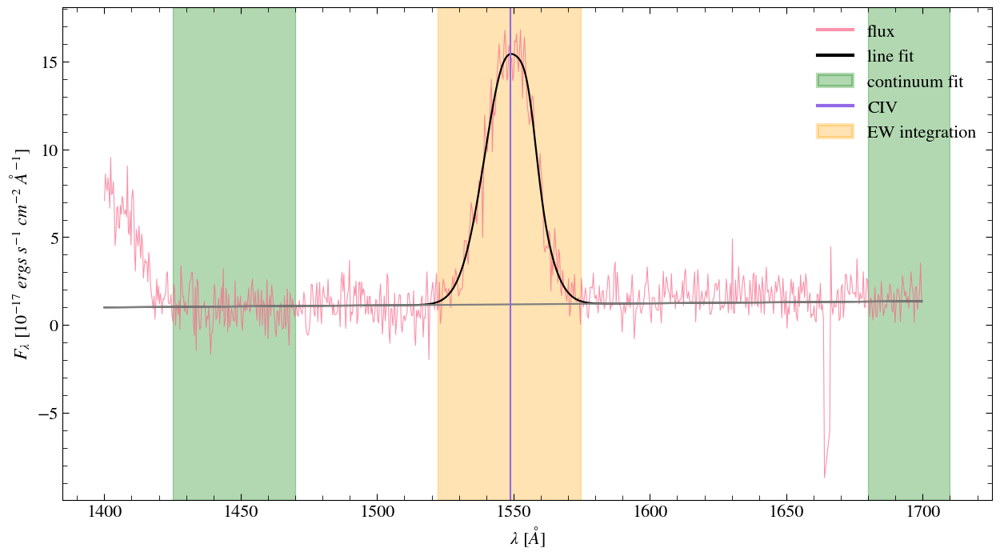


                SDSS: 232326.17-010033.1
                FWHM: 4149.485 vs 3989.27 (Hamann)
                REW: 280.216 vs 255.993 (Hamann)
                kt80: 0.436 vs 0.371 (Hamann)
    


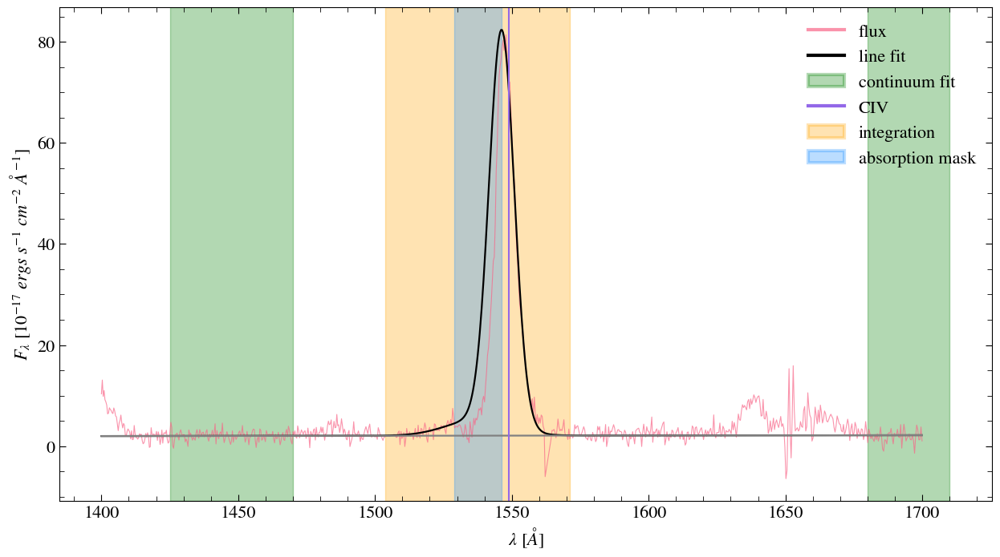


                SDSS: 232828.47+044346.8
                FWHM: 2140.443 vs 1583.693 (Hamann)
                REW: 362.377 vs 358.596 (Hamann)
                kt80: 0.366 vs 0.352 (Hamann)
    


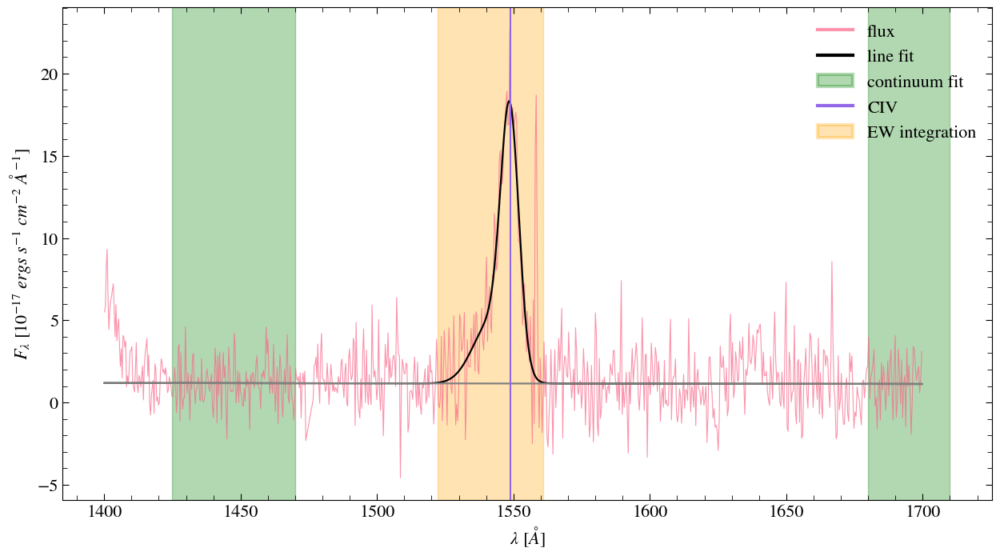


                SDSS: 233636.99+065231.0
                FWHM: 1690.035 vs 1483.559 (Hamann)
                REW: 163.378 vs 128.271 (Hamann)
                kt80: 0.3 vs 0.258 (Hamann)
    


In [13]:
for i in range(len(data)):
    lam = np.array(data["wavelength"][i])
    flux = np.array(data["flux"][i])
    ivar = np.array(data["ivar"][i])
    z = data["redshift"][i]

    lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

    absorption_found, line_stats = check(lam, flux, ivar)

    out_str = f'''
                SDSS: {data["sdss_name"][i]}
                FWHM: {round(line_stats["fwhm_kms"],3)} vs {round(data["fwhm"][i],3)} (Hamann)
                REW: {round(line_stats["ew_aa"],3)} vs {round(data["rew"][i],3)} (Hamann)
                kt80: {round(line_stats["kt80"],3)} vs {round(data["kt80"][i],3)} (Hamann)
    '''
    print(out_str)

    data["absorption_detected"][i] = absorption_found
    data["absorption_relevant"][i] = input(f"{data['sdss_name'][i]}")

In [ ]:
data["absorption_relevant"] = data["absorption_relevant"].map({"f":False,"t":True,"-":pd.NA})

# data.to_csv(relevant_erq_data_path)
data = pd.read_csv(relevant_erq_data_path,index_col=0)

data

,sdss_name,z_dr12,rew,fwhm,kt80,specid,redshift,redshift_warning,wavelength,flux,ivar,absorption_detected,absorption_relevant
0,000610.67+121501.2,2.309943,106.996659,4540.061012,0.372288,6360287837779417088,2.309787,0,"[3553.8574198608, 3554.6758199907, 3555.494408...","[1.9252539873, 1.9251964092, 1.3102685213, 0.6...","[0.0, 0.11758627, 0.0, 0.19981963930000002, 0....",False,False
1,000746.19+122223.9,2.429000,219.633801,2432.830081,0.284162,6360267496814303232,2.433351,0,"[3553.8574198608, 3554.6758199907, 3555.494408...","[-5.924967289, -5.9247941971, 3.1096043587, 12...","[0.0, 0.11920769510000001, 0.0, 0.0926503986, ...",False,True
2,002400.25+245031.9,2.809255,143.689957,3523.281699,0.372201,7069533316387723264,2.789841,4,"[3558.7706484879, 3559.5901800608, 3560.409900...","[-0.8786045313, -0.8787579536000001, 0.1475744...","[0.0, 0.0552793145, 0.0, 0.048356846, 0.047023...",False,True
3,004713.21+264024.7,2.563943,100.506344,3685.427543,0.325082,7077626822452860928,2.553878,0,"[3561.2298094276, 3562.0499073084, 3562.870194...","[-1.7795865536000002, -1.7798964977, -1.780206...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",True,True
4,005044.95-021217.6,2.254000,147.225015,4343.057592,0.193256,4920452066097518592,2.253475,0,"[3553.0392081527, 3553.8574198608, 3554.675819...","[1.8903125525000002, 1.8905686140000002, 1.890...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,223754.52+065026.6,2.608809,140.676812,1390.574742,0.356129,5694835917824743424,2.614897,0,"[3561.2298094276, 3562.0499073084, 3562.870194...","[14.607211113, -22.7902507782, 20.6671199799, ...","[0.09246767310000001, 0.1343497932, 0.12748730...",False,True
93,225438.30+232714.5,3.087494,415.244897,4411.577590,0.358143,7417535898320132096,3.087466,0,"[3568.6174928348, 3569.4392919885, 3570.261280...","[-1.3009853363000001, -0.3360394239, -0.240143...","[0.2848583758, 0.26905199890000003, 0.28210353...",False,True
94,232326.17-010033.1,2.356070,255.993179,3989.269919,0.370693,4740064262789289984,2.350765,0,"[3564.5113342624, 3565.3321878293, 3566.153230...","[7.0590491295, -4.7015686035, 7.8777022362, 1....","[0.0343443416, 0.1265157163, 0.126755625, 0.13...",False,False
95,232828.47+044346.8,2.563872,358.595759,1583.693351,0.352179,4822392127110797312,2.568358,0,"[3553.0392081527, 3553.8574198608, 3554.675819...","[1.856464982, 1.8564176559, 1.8563705683, 1.85...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",True,True
